# Práctica 3: A\*, Hill Climbing y Optimización de Redes

Fabian Prado - 23427 | CC3074 Modelación y Simulación, UVG | 2026-10-06

**Pregunta:** ¿Qué solución encuentran Hill Climbing, A\*, Edmonds-Karp y el flujo de costo mínimo en sus tres problemas, y cómo se comprueba si es la mejor posible?

El laboratorio tiene tres problemas, cada uno con su algoritmo:

1. **Hill Climbing** para el agente viajero: recorrer las ciudades 2 a 7 saliendo y volviendo a la ciudad 1 con la menor distancia.
2. **A\*** para la ruta más corta de O a T en la red del guardabosques.
3. **Flujo Máximo (Edmonds-Karp) y Costo Mínimo** para enviar suministros de S a T.

Todos los algoritmos están implementados desde cero, solo con la librería estándar de Python (`heapq`, `collections`, `random`, `itertools`, `math`) y `matplotlib` para las gráficas, como pide el enunciado.

## Mapa del notebook

1. Imports y configuración
2. Obtención de datos
3. Preparación de datos
4. Variables
5. Modelos y métricas
6. Gráficas
7. Ejecución
8. Conclusiones

Las secciones 2 a 6 solo definen funciones, separadas por parte. La sección 7 las ejecuta en orden y cada resultado lleva su interpretación.

## Dónde está cada actividad

| Parte | Actividades del enunciado | Paso en la sección 7 |
|---|---|---|
| 1. Hill Climbing | 1. `distancia_tour` y tour inicial | 7.1 |
| | 2. `vecinos` por inversión | 7.2 |
| | 3 y 4. Hill Climbing de máximo descenso con registro | 7.3 |
| | 5. 100 reinicios aleatorios | 7.4 |
| | Extra: todos los tours válidos por fuerza bruta | 7.5 |
| | 6. Gráfica del mejor recorrido | 7.6 |
| | Preguntas de análisis | después de 7.6 |
| 2. A\* | 7. `heuristica` euclidiana | 7.7 |
| | 8, 9 y 10. A\* con `heapq`, registro, ruta y costo | 7.8 |
| | 11. A\* con h(n) = 0 | 7.9 |
| | 12. Gráfica de la red | 7.10 |
| | Preguntas de análisis | después de 7.10 |
| 3A. Flujo Máximo | 13. Red residual | 7.11 |
| | 14, 15 y 16. Edmonds-Karp con registro y flujo por tramo | 7.12 |
| | 17. Verificación de capacidad y conservación | 7.13 |
| | Extra: corte mínimo | 7.14 |
| 3B. Costo Mínimo | 18. Capacidad, costo y flujo por arista | 7.15 |
| | 19 a 23. Costo mínimo con registro | 7.16 |
| | 24. Reporte final | 7.17 |
| | Extra: costo de la distribución de Edmonds-Karp | 7.18 |
| | Preguntas de análisis | después de 7.18 |
| Integración | Tabla comparativa y conclusión | 8 |

## 1. Imports y configuración

Todas las librerías, la semilla y la paleta en una sola celda. Solo se usan las librerías que permite el enunciado: nada de `numpy`, `pandas` ni `networkx`, así que las tablas se imprimen con texto. `SEED` fija los reinicios aleatorios de Hill Climbing para que cualquier corrida dé los mismos números.

In [1]:
import heapq
import itertools
import math
import random
from collections import Counter, deque
from pathlib import Path

import matplotlib.pyplot as plt

SEED = 42
ROOT = Path.cwd()
FIG_DIR = ROOT / "figuras"
FIG_DIR.mkdir(exist_ok=True)

# Forest, leaf, ochre, lake, clay: greens first, earth and water tones for more series.
PALETTE = ["#0E4D45", "#3F8A26", "#B07D2B", "#3A7CA5", "#A4493D"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "figure.figsize": (16, 9),
    "figure.facecolor": "white",
    "legend.frameon": True,
})

## 2. Obtención de datos

No hay archivos externos: los datos de cada parte se copian del enunciado en una función que los devuelve tal cual.

- **Parte 1.** `get_carreteras`: las 13 carreteras entre las 7 ciudades como (ciudad, ciudad, distancia). Son de doble sentido. Si un par de ciudades no aparece, no hay carretera directa entre ellas.
- **Parte 2.** `get_caminos`: los 12 caminos del parque como (estación, estación, distancia), de doble sentido. `get_coordenadas`: la posición (x, y) de cada estación. Las coordenadas no se usan para medir caminos, solo para la heurística y para dibujar.
- **Parte 3.** `get_tramos`: los 12 tramos de la red de distribución como (origen, destino, capacidad, costo por unidad). Son de **un solo sentido** (de S hacia T). Las capacidades son las del laboratorio base; los costos los agrega el enunciado para la parte de Costo Mínimo.

In [2]:
# Part 1: traveling salesman
def get_carreteras():
    """Roads of part 1 as (city, city, distance). Two-way; a pair that is not listed has no road."""
    return [
        (1, 2, 12), (1, 3, 10), (1, 7, 12),
        (2, 3, 8), (2, 4, 12),
        (3, 4, 11), (3, 5, 3), (3, 7, 9),
        (4, 5, 11), (4, 6, 10),
        (5, 6, 6), (5, 7, 7),
        (6, 7, 9),
    ]

In [3]:
# Part 2: shortest path in the park
def get_caminos():
    """Two-way paths of part 2 as (station, station, distance)."""
    return [
        ("O", "A", 2), ("O", "B", 5), ("O", "C", 4),
        ("A", "B", 2), ("A", "D", 7),
        ("B", "C", 1), ("B", "D", 4), ("B", "E", 3),
        ("C", "E", 4),
        ("D", "E", 1), ("D", "T", 5),
        ("E", "T", 7),
    ]


def get_coordenadas():
    """(x, y) of each station, used only by the Euclidean heuristic and the plot."""
    return {"O": (0.0, 0.0), "A": (1.5, 1.2), "B": (2.5, 0.0), "C": (2.8, -0.8),
            "D": (5.5, 1.0), "E": (5.2, 0.2), "T": (9.0, 0.5)}

In [4]:
# Part 3: supply network
def get_tramos():
    """One-way edges of part 3 as (from, to, capacity, cost per unit)."""
    return [
        ("S", "A", 5, 2), ("S", "B", 7, 1), ("S", "C", 4, 3),
        ("A", "B", 1, 1), ("A", "D", 3, 2),
        ("B", "C", 2, 1), ("B", "D", 4, 3), ("B", "E", 5, 2),
        ("C", "E", 4, 1),
        ("D", "T", 9, 2),
        ("E", "D", 1, 1), ("E", "T", 6, 3),
    ]

## 3. Preparación de datos

Convierte los datos de cada parte a la estructura que usa su algoritmo.

- **Parte 1.** `construir_distancias`: tabla `distancias[a][b]` en los dos sentidos, porque las carreteras son de doble sentido. Un par sin carretera simplemente no está en la tabla, y así es fácil detectar un tour no válido.
- **Parte 2.** Los caminos también son de doble sentido, así que el grafo de A\* es la misma tabla: `grafo = construir_distancias(get_caminos())`, donde `grafo[u]` da los vecinos de `u` con la distancia a cada uno.
- **Parte 3.** `construir_capacidades_costos`: dos tablas dirigidas, `capacidades[u][v]` y `costos[u][v]`. `construir_residual` arma la **red residual** (actividad 13): cada tramo u > v guarda cuánto le queda libre, y se agrega una **arista de regreso** v > u con capacidad 0. Cuando se mandan k unidades por u > v, su capacidad baja k y la de v > u sube k. Así, más adelante, un camino puede usar v > u para "devolver" flujo y corregir una decisión anterior. `flujos_desde_residual` recupera el flujo de cada tramo: capacidad original menos lo que quedó libre.

In [5]:
# Part 1: traveling salesman
def construir_distancias(carreteras):
    """Symmetric table distancias[a][b]; a pair with no road is missing from the table."""
    distancias = {}
    for a, b, d in carreteras:
        distancias.setdefault(a, {})[b] = d
        distancias.setdefault(b, {})[a] = d
    return distancias

In [6]:
# Part 3: capacity and cost tables, residual network
def construir_capacidades_costos(tramos):
    """Directed tables capacidades[u][v] and costos[u][v]; every node gets an entry, even T with no exits."""
    capacidades, costos = {}, {}
    for u, v, cap, costo in tramos:
        capacidades.setdefault(u, {})[v] = cap
        costos.setdefault(u, {})[v] = costo
        capacidades.setdefault(v, {})
        costos.setdefault(v, {})
    return capacidades, costos


def construir_residual(capacidades):
    """Residual network: each edge u->v starts with its capacity and gets a back edge v->u with capacity 0.

    Opposite edges u->v and v->u in the input are rejected: the back edge would overwrite a real edge.
    """
    residual = {u: {} for u in capacidades}
    for u in capacidades:
        for v, cap in capacidades[u].items():
            if u in capacidades[v]:
                raise ValueError(f"opposite edges {u}->{v} and {v}->{u} are not supported")
            residual[u][v] = cap
            residual[v][u] = 0
    return residual


def flujos_desde_residual(capacidades, residual):
    """Flow on each original edge: its capacity minus what is still free in the residual network."""
    return {(u, v): cap - residual[u][v] for u in capacidades for v, cap in capacidades[u].items()}

## 4. Variables

Aquí van las funciones que miden qué tan buena es una solución o un nodo: lo que cada algoritmo usa para decidir.

- **Parte 1.** `distancia_tour` es la **función objetivo** de Hill Climbing: suma la distancia de cada tramo del tour. Devuelve `None` (no válido) si un tramo usa una carretera que no existe, o si el tour no es un ciclo completo: debe empezar y terminar en la misma ciudad y pasar una sola vez por cada una de las demás.
- **Parte 2.** `heuristica` es h(n), la distancia en línea recta desde la estación hasta la meta. `heuristica_cero` es h(n) = 0, la versión sin información que se usa en la actividad 11. `heuristica_desde_tabla` lee h(n) de una tabla; se usa con el costo real que falta, h\*(n), para ver cómo se comporta A\* con una heurística perfecta. `revisar_heuristica` comprueba camino por camino que h sea **consistente**: al recorrer un camino de longitud w, h no puede bajar más de w. Una heurística consistente con h(meta) = 0 tampoco sobreestima el costo real (es **admisible**), y eso garantiza que A\* devuelve una ruta óptima.

In [7]:
# Part 1: objective function of Hill Climbing
def distancia_tour(tour, distancias):
    """Total distance of a closed tour, or None when it is not valid (missing road or not a full cycle)."""
    if tour[0] != tour[-1] or sorted(tour[:-1]) != sorted(distancias):
        return None
    total = 0
    for a, b in zip(tour, tour[1:]):
        if b not in distancias[a]:
            return None
        total += distancias[a][b]
    return total

In [8]:
# Part 2: heuristics for A*
def heuristica(nodo, meta, coordenadas):
    """Straight-line distance from nodo to meta: the Euclidean estimate of the remaining cost."""
    (x1, y1), (x2, y2) = coordenadas[nodo], coordenadas[meta]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def heuristica_cero(nodo, meta, coordenadas):
    """h(n) = 0: no estimate of the remaining cost, which turns A* into Dijkstra."""
    return 0.0


def heuristica_desde_tabla(tabla):
    """Heuristic that reads h(n) from a precomputed table; used for the perfect heuristic h*(n)."""
    return lambda nodo, meta, coordenadas: tabla[nodo]


def revisar_heuristica(caminos, coordenadas, meta, h=heuristica):
    """Consistency check per path u-v: h can drop at most the path length, |h(u) - h(v)| <= w."""
    filas = []
    for u, v, w in caminos:
        hu, hv = h(u, meta, coordenadas), h(v, meta, coordenadas)
        filas.append({"camino": [u, v], "distancia": w, "h_u": hu, "h_v": hv, "dif_h": abs(hu - hv),
                      "consistente": abs(hu - hv) <= w})
    return filas

## 5. Modelos y métricas

Los algoritmos de cada parte y la referencia contra la que se comparan.

| Parte | Algoritmo | Referencia | Métrica | Por qué esa métrica |
|---|---|---|---|---|
| 1 | Hill Climbing de máximo descenso, con y sin reinicios | Fuerza bruta sobre todos los tours (solo hay 720 órdenes posibles) | Distancia del tour y % de reinicios que llegan al óptimo | La fuerza bruta da la respuesta exacta, así que se sabe si Hill Climbing se quedó en un óptimo local |
| 2 | A\* con heurística euclidiana | A\* con h = 0 (Dijkstra) y todas las rutas simples de O a T | Costo de la ruta y nodos expandidos | Las dos versiones de A\* son óptimas, así que el costo debe coincidir; la diferencia está en cuánto exploran |
| 3A | Edmonds-Karp | Corte mínimo de la red residual final | Flujo total de S a T | Si el flujo es igual a la capacidad de un corte, ningún flujo puede ser mayor: es la prueba de que es máximo |

**Parte 1, Hill Climbing.** Una **solución** es un tour que sale de la ciudad 1, pasa una vez por cada otra ciudad y vuelve a la 1. Un **vecino** es el tour que resulta de invertir un sub-recorrido: por ejemplo, invertir 3-4-5 en 1-2-3-4-5-6-7-1 da 1-2-5-4-3-6-7-1. La ciudad 1 nunca se mueve, así que con 6 ciudades libres hay 15 inversiones posibles. Un vecino que usa una carretera inexistente se descarta.

- `vecinos`: genera las 15 inversiones y devuelve las válidas con su distancia y el tramo invertido.
- `hill_climbing`: máximo descenso. En cada iteración evalúa **todos** los vecinos válidos y se mueve al de menor distancia, solo si es estrictamente mejor que el tour actual. Si ninguno mejora, se detiene: está en un **óptimo local**. Si hay empate entre vecinos, gana el primero en el orden en que se generan.
- `tour_aleatorio_valido` y `hill_climbing_reinicios`: repiten Hill Climbing desde tours al azar y se quedan con el mejor. El tour al azar se genera barajando las ciudades 2 a 7 hasta que salga uno válido, porque la mayoría de los órdenes usa alguna carretera que no existe.
- `fuerza_bruta_tours`: evalúa los 720 órdenes posibles. No es parte de Hill Climbing; sirve para saber cuál es el óptimo real.

**Parte 2, A\*.** A\* mantiene una **lista abierta** con los nodos descubiertos que todavía no ha expandido, ordenada por f(n) = g(n) + h(n):

- g(n) es lo que ya costó llegar a n desde O.
- h(n) es la estimación de lo que falta hasta T.

En cada paso saca de la lista abierta el nodo con menor f (eso hace `heapq`), lo **expande** (revisa sus vecinos) y lo pasa a la lista cerrada. Termina cuando la meta sale de la lista abierta, no cuando aparece por primera vez, porque hasta ese momento podría haber un camino más barato pendiente.

- `a_estrella`: si se encuentra un camino más corto a un nodo, se mete otra entrada al heap con el nuevo g. La entrada vieja queda en el heap y se ignora cuando sale, porque el nodo ya está cerrado. Los empates en f se rompen por menor h (el nodo más cerca de la meta) y luego por nombre. El parámetro `h` permite usar `heuristica_cero` para la actividad 11.
- `contenido_abierta`: muestra la lista abierta como texto, con una entrada por nodo (su mejor f) en el orden en que saldrían.
- `costos_reales`: el costo real que falta desde cada nodo hasta la meta, h\*(n), calculado con A\* y h = 0 desde cada nodo.
- `rutas_simples`: lista todas las rutas de O a T que no repiten estación, con su costo. Es fuerza bruta, posible porque la red es pequeña, y sirve para comprobar el óptimo y ver si hay empates.

**Parte 3A, Edmonds-Karp.** Mientras exista un **camino aumentante**, un camino de S a T en la red residual donde todos los tramos tienen capacidad libre, se manda por él tanto flujo como permite su tramo más angosto (el **cuello de botella**).

- `bfs_camino`: busca el camino aumentante con BFS, así que siempre encuentra el de **menos tramos**. Esa es la diferencia entre Edmonds-Karp y Ford-Fulkerson genérico, y garantiza que termina en pocas iteraciones.
- `edmonds_karp`: repite BFS, cuello de botella y actualización de la red residual hasta que no haya camino. Registra cada iteración, incluyendo qué tramo fue el cuello y si el camino usó alguna arista de regreso.
- `verificar_flujo` (actividad 17): revisa que ningún tramo pase su capacidad y que en cada nodo intermedio entre lo mismo que sale.
- `corte_minimo`: al final, los nodos que todavía se alcanzan desde S en la red residual forman un lado del corte. Los tramos originales que cruzan de ese lado al otro están todos llenos, y su capacidad total es igual al flujo máximo (**teorema de flujo máximo y corte mínimo**). `capacidad_corte` mide cualquier otro corte para comparar.

In [9]:
# Part 1: Hill Climbing for the traveling salesman
def vecinos(tour, distancias, incluir_invalidos=False):
    """Tours made by reversing tour[i..j] with the first and last city fixed.

    Returns (neighbor, distance, reversed segment). Invalid neighbors are dropped, or kept with
    distance None when incluir_invalidos is True.
    """
    salida = []
    n = len(tour) - 1  # positions 0 and n hold the fixed start city
    for i in range(1, n - 1):
        for j in range(i + 1, n):
            vecino = tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]
            d = distancia_tour(vecino, distancias)
            if d is not None or incluir_invalidos:
                salida.append((vecino, d, tour[i:j + 1]))
    return salida


def hill_climbing(tour_inicial, distancias):
    """Steepest descent: move to the best valid neighbor while it is strictly shorter.

    Returns the final tour, its distance and one log row per iteration. The last row is the
    iteration where no neighbor improves.
    """
    actual = list(tour_inicial)
    d_actual = distancia_tour(actual, distancias)
    if d_actual is None:
        raise ValueError(f"initial tour {actual} is not valid")
    registro = []
    while True:
        candidatos = vecinos(actual, distancias)
        if candidatos:
            mejor, d_mejor, tramo = min(candidatos, key=lambda c: c[1])
        else:
            mejor, d_mejor, tramo = None, math.inf, None
        registro.append({"iteracion": len(registro) + 1, "tour_actual": actual, "distancia": d_actual,
                         "mejor_vecino": mejor, "dist_vecino": d_mejor, "tramo_invertido": tramo,
                         "mejora": d_mejor < d_actual})
        if d_mejor >= d_actual:
            return actual, d_actual, registro
        actual, d_actual = mejor, d_mejor


def tour_aleatorio_valido(rng, distancias, inicio=1):
    """Random valid tour: shuffle the other cities until every leg uses an existing road.

    Returns the tour and how many shuffles it took.
    """
    otras = sorted(c for c in distancias if c != inicio)
    intentos = 0
    while True:
        intentos += 1
        rng.shuffle(otras)
        tour = [inicio] + otras + [inicio]
        if distancia_tour(tour, distancias) is not None:
            return tour, intentos


def hill_climbing_reinicios(distancias, n_reinicios, seed=SEED):
    """Hill Climbing from n random valid tours. Returns the best tour, its distance and one row per restart."""
    rng = random.Random(seed)
    resultados = []
    for k in range(1, n_reinicios + 1):
        inicio, intentos = tour_aleatorio_valido(rng, distancias)
        final, d_final, registro = hill_climbing(inicio, distancias)
        resultados.append({"reinicio": k, "intentos": intentos, "tour_inicial": inicio,
                           "dist_inicial": registro[0]["distancia"], "tour_final": final,
                           "dist_final": d_final, "movimientos": len(registro) - 1})
    mejor = min(resultados, key=lambda r: r["dist_final"])
    return mejor["tour_final"], mejor["dist_final"], resultados


def fuerza_bruta_tours(distancias, inicio=1):
    """Every valid tour with its distance, shortest first: the exact answer to compare Hill Climbing against."""
    otras = sorted(c for c in distancias if c != inicio)
    validos = []
    for orden in itertools.permutations(otras):
        tour = [inicio, *orden, inicio]
        d = distancia_tour(tour, distancias)
        if d is not None:
            validos.append((d, tour))
    return sorted(validos)

In [10]:
# Part 2: A* shortest path
def reconstruir_camino(padre, meta):
    """Follow the parent links back from meta to the start."""
    camino, nodo = [], meta
    while nodo is not None:
        camino.append(nodo)
        nodo = padre[nodo]
    return camino[::-1]


def contenido_abierta(abierta, cerrados):
    """Open list as text 'node(f)', one entry per node with its best f, in the order heapq would pop them."""
    vistos, partes = set(), []
    for f, _, nodo in sorted(abierta):
        if nodo not in cerrados and nodo not in vistos:
            vistos.add(nodo)
            partes.append(f"{nodo}({f:.2f})")
    return ", ".join(partes) if partes else "vacía"


def a_estrella(grafo, coordenadas, inicio, meta, h=heuristica):
    """A* with a heapq open list. Returns the path, its cost and one log row per expanded node.

    Heap entries are (f, h, node): ties in f go to the smaller h, then to the node name.
    Closed nodes are never reopened, which is safe because the heuristic is consistent (checked in 7.7).
    """
    g = {inicio: 0}
    padre = {inicio: None}
    h_inicio = h(inicio, meta, coordenadas)
    abierta = [(g[inicio] + h_inicio, h_inicio, inicio)]
    cerrados = set()
    registro = []
    while abierta:
        f, hn, nodo = heapq.heappop(abierta)
        if nodo in cerrados:
            continue  # stale entry: the node was already expanded with a smaller g
        cerrados.add(nodo)
        if nodo != meta:
            for vecino, w in grafo[nodo].items():
                nuevo_g = g[nodo] + w
                if vecino not in cerrados and nuevo_g < g.get(vecino, math.inf):
                    g[vecino] = nuevo_g
                    padre[vecino] = nodo
                    hv = h(vecino, meta, coordenadas)
                    heapq.heappush(abierta, (nuevo_g + hv, hv, vecino))
        registro.append({"paso": len(registro) + 1, "expandido": nodo, "g": g[nodo], "h": hn, "f": f,
                         "lista_abierta": contenido_abierta(abierta, cerrados)})
        if nodo == meta:
            return reconstruir_camino(padre, meta), g[meta], registro
    return None, math.inf, registro


def costos_reales(grafo, coordenadas, meta):
    """True remaining cost h*(n) from every node to meta, with A* and h = 0 (Dijkstra) from each node."""
    return {n: a_estrella(grafo, coordenadas, n, meta, h=heuristica_cero)[1] for n in grafo}


def rutas_simples(grafo, inicio, meta):
    """Every path from inicio to meta that repeats no node, with its cost, cheapest first (brute force reference)."""
    rutas = []

    def extender(camino, costo):
        if camino[-1] == meta:
            rutas.append((costo, camino))
            return
        for vecino, w in grafo[camino[-1]].items():
            if vecino not in camino:
                extender(camino + [vecino], costo + w)

    extender([inicio], 0)
    return sorted(rutas)

In [11]:
# Part 3A: Edmonds-Karp max flow
def bfs_camino(residual, fuente, destino):
    """Augmenting path with the fewest edges, using only residual edges with capacity left; None if there is none."""
    padre = {fuente: None}
    cola = deque([fuente])
    while cola:
        u = cola.popleft()
        for v, cap in residual[u].items():
            if cap > 0 and v not in padre:
                padre[v] = u
                if v == destino:
                    return reconstruir_camino(padre, destino)
                cola.append(v)
    return None


def edmonds_karp(capacidades, fuente, destino):
    """Max flow with BFS augmenting paths. Returns the max flow, the flow per edge, the log and the final residual."""
    residual = construir_residual(capacidades)
    total = 0
    registro = []
    while True:
        camino = bfs_camino(residual, fuente, destino)
        if camino is None:
            return total, flujos_desde_residual(capacidades, residual), registro, residual
        tramos = list(zip(camino, camino[1:]))
        cuello = min(residual[u][v] for u, v in tramos)
        limitantes = [[u, v] for u, v in tramos if residual[u][v] == cuello]
        for u, v in tramos:
            residual[u][v] -= cuello
            residual[v][u] += cuello
        total += cuello
        registro.append({"iteracion": len(registro) + 1, "camino": camino, "cuello_de_botella": cuello,
                         "tramo_limitante": ", ".join(formato(t) for t in limitantes),
                         "usa_regreso": any(v not in capacidades[u] for u, v in tramos),
                         "flujo_enviado": cuello, "flujo_acumulado": total})


def verificar_flujo(capacidades, flujos, fuente, destino):
    """Capacity check per edge and conservation check per intermediate node, as two lists of rows."""
    por_tramo = [{"tramo": [u, v], "flujo": f, "capacidad": capacidades[u][v], "cumple": 0 <= f <= capacidades[u][v]}
                 for (u, v), f in flujos.items()]
    por_nodo = []
    for n in capacidades:
        if n not in (fuente, destino):
            entra = sum(f for (u, v), f in flujos.items() if v == n)
            sale = sum(f for (u, v), f in flujos.items() if u == n)
            por_nodo.append({"nodo": n, "entra": entra, "sale": sale, "cumple": entra == sale})
    return por_tramo, por_nodo


def corte_minimo(residual, capacidades, fuente):
    """Nodes still reachable from fuente in the final residual network, and the original edges leaving that set."""
    alcanzables = {fuente}
    cola = deque([fuente])
    while cola:
        u = cola.popleft()
        for v, cap in residual[u].items():
            if cap > 0 and v not in alcanzables:
                alcanzables.add(v)
                cola.append(v)
    lado = [n for n in capacidades if n in alcanzables]  # keep table order, sets have no fixed order
    corte = [(u, v) for u in lado for v in capacidades[u] if v not in alcanzables]
    return lado, corte


def capacidad_corte(capacidades, lado_fuente):
    """Total capacity of the original edges going from lado_fuente to the rest of the nodes."""
    return sum(cap for u in lado_fuente for v, cap in capacidades[u].items() if v not in lado_fuente)

## 6. Gráficas

Funciones para mostrar resultados. `imprimir_tabla` imprime los registros por iteración como tabla de texto (no se usa `pandas`) y `formato` decide cómo se ve cada valor: rutas unidas con guiones, decimales con 2 cifras. Las funciones de gráficas guardan la figura en `figuras/` y devuelven `fig, ax`.

- **Parte 1.** `plot_tours` dibuja uno o varios tours lado a lado sobre la red de carreteras. El enunciado no da coordenadas de las ciudades, así que se colocan en un círculo **solo para dibujar**: la posición no significa nada, lo que importa son las conexiones y sus distancias. `plot_reinicios` cuenta cuántos reinicios empiezan y terminan en cada distancia, para ver qué hace Hill Climbing con cada arranque.
- **Parte 2.** `plot_red` dibuja la red en sus coordenadas reales con la distancia de cada camino. Por cada búsqueda hay un panel con la ruta resaltada; los nodos expandidos van rellenos con su número de orden y los no expandidos van vacíos, para comparar cuánto exploró cada versión.
- **Parte 3.** `plot_flujos` dibuja la red de distribución de izquierda (S) a derecha (T); las posiciones de `POSICIONES_RED` son solo para dibujar. Cada tramo muestra flujo/capacidad y su costo por unidad, el grosor crece con el flujo y los tramos sin flujo van punteados. Opcionalmente marca en rojo los tramos de un corte.

In [12]:
ROLE = {"actual": "#0E4D45", "model": "#3A7CA5", "compare": "#B07D2B",
        "up": "#3F8A26", "down": "#A4493D", "missing": "#C9CFCB", "shade": "#EEF0EE"}


def style_ax(ax, title, xlabel, ylabel, subtitle=None):
    """Title, axis labels and clean spines in the house style."""
    ax.set_title(title + (f"\n{subtitle}" if subtitle else ""), fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.grid(axis="y", alpha=0.3)


def label_points(ax, x, y, fmt="{:.1f}", every=1, color=None):
    """Bold value labels past the end of every Nth point or bar; negatives go below, in clay."""
    y = list(y)
    span = (max(y) - min(y)) or abs(max(y)) or 1
    for i, (xi, yi) in enumerate(zip(x, y)):
        if i % every == 0:
            below = yi < 0
            ax.text(xi, yi + (-1 if below else 1) * span * 0.03, fmt.format(yi), ha="center",
                    va="top" if below else "bottom", fontsize=10, fontweight="bold",
                    color=ROLE["down"] if below else (color or ROLE["actual"]))


def ref_line(ax, value, label, kind="target"):
    """Target (dashed clay), average (solid ochre) or zero (thin gray) line."""
    styles = {"target": dict(color=ROLE["down"], linestyle="--", linewidth=1.8),
              "average": dict(color=ROLE["compare"], linestyle="-", linewidth=2),
              "zero": dict(color="#444444", linestyle="--", linewidth=0.8)}
    ax.axhline(value, label=label, zorder=2, **styles[kind])


def formato(valor):
    """Text for one table cell: routes joined with dashes, floats with 2 decimals, None as a dash."""
    if valor is None:
        return "-"
    if isinstance(valor, bool):
        return "sí" if valor else "no"
    if isinstance(valor, (list, tuple)):
        return "-".join(str(v) for v in valor)
    if isinstance(valor, float):
        return "inf" if math.isinf(valor) else f"{valor:.2f}"
    return str(valor)


def imprimir_tabla(filas, columnas):
    """Print a list of dicts as a fixed-width text table, one row per dict, in the given column order."""
    texto = [[formato(f[c]) for c in columnas] for f in filas]
    anchos = [max([len(c)] + [len(t[i]) for t in texto]) for i, c in enumerate(columnas)]
    print(" | ".join(c.ljust(a) for c, a in zip(columnas, anchos)))
    print("-+-".join("-" * a for a in anchos))
    for t in texto:
        print(" | ".join(v.ljust(a) for v, a in zip(t, anchos)))

In [13]:
# Part 1: tours and restarts
def posiciones_circulo(nodos):
    """Drawing-only positions: nodes evenly spaced on a circle, the first one at the top, clockwise."""
    n = len(nodos)
    return {c: (math.cos(math.pi / 2 - 2 * math.pi * k / n), math.sin(math.pi / 2 - 2 * math.pi * k / n))
            for k, c in enumerate(nodos)}


def plot_tours(paneles, distancias, archivo, titulo):
    """One panel per (name, tour, color): every road in gray with its distance, the tour as thick arrows."""
    pos = posiciones_circulo(sorted(distancias))
    fig, axes = plt.subplots(1, len(paneles), figsize=(8 * len(paneles), 8.5))
    axes = [axes] if len(paneles) == 1 else list(axes)
    for ax, (nombre, tour, color) in zip(axes, paneles):
        tramos = {frozenset(p) for p in zip(tour, tour[1:])}
        for a in distancias:
            for b, d in distancias[a].items():
                if a < b and frozenset((a, b)) not in tramos:
                    (xa, ya), (xb, yb) = pos[a], pos[b]
                    ax.plot([xa, xb], [ya, yb], color=ROLE["missing"], linewidth=1.5, zorder=1)
                    ax.text((xa + xb) / 2, (ya + yb) / 2, str(d), color="#7F8F8B", fontsize=10, ha="center",
                            va="center", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"), zorder=2)
        for a, b in zip(tour, tour[1:]):
            (xa, ya), (xb, yb) = pos[a], pos[b]
            ax.annotate("", xy=(xb, yb), xytext=(xa, ya), zorder=3,
                        arrowprops=dict(arrowstyle="-|>", color=color, linewidth=3.5, shrinkA=20, shrinkB=20,
                                        mutation_scale=22))
            ax.text((xa + xb) / 2, (ya + yb) / 2, str(distancias[a][b]), color=color, fontsize=12,
                    fontweight="bold", ha="center", va="center", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, lw=1))
        for c, (x, y) in pos.items():
            inicio = c == tour[0]
            ax.scatter([x], [y], s=900, color=ROLE["actual"] if inicio else "white",
                       edgecolor=ROLE["actual"], linewidth=2.5, zorder=5)
            ax.text(x, y, str(c), ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if inicio else ROLE["actual"], zorder=6)
        ax.set_title(f"{nombre}\n{formato(tour)} | distancia {distancia_tour(tour, distancias)}",
                     fontsize=14, fontweight="bold", pad=12)
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect("equal")
        ax.axis("off")
    fig.suptitle(titulo, fontsize=18, fontweight="bold", y=1.04)
    fig.tight_layout()
    fig.savefig(FIG_DIR / archivo, bbox_inches="tight")
    return fig, axes


def plot_reinicios(reinicios, marcado, archivo, etiqueta="mejor", subtitulo=None):
    """Grouped bars: how many restarts start and end at each tour distance; the marcado distance gets a label."""
    inicio = Counter(r["dist_inicial"] for r in reinicios)
    final = Counter(r["dist_final"] for r in reinicios)
    valores = sorted(set(inicio) | set(final))
    x = list(range(len(valores)))
    w = 0.38
    fig, ax = plt.subplots(figsize=(16, 7))
    for desplazamiento, conteo, color, nombre in ((-w / 2, inicio, ROLE["compare"], "Tour inicial al azar"),
                                                  (w / 2, final, ROLE["actual"], "Después de Hill Climbing")):
        xs = [i + desplazamiento for i in x]
        ys = [conteo[v] for v in valores]
        ax.bar(xs, ys, w, color=color, edgecolor="white", linewidth=0.5, label=nombre)
        label_points(ax, xs, ys, fmt="{:.0f}", color=color)
    ax.set_xticks(x, [f"{v}\n({etiqueta})" if v == marcado else str(v) for v in valores])
    ax.set_ylim(0, max(max(inicio.values()), max(final.values())) * 1.15)
    style_ax(ax, f"{len(reinicios)} reinicios de Hill Climbing: distancia del tour al empezar y al terminar",
             "Distancia total del tour", "Cantidad de reinicios", subtitle=subtitulo)
    ax.legend(loc="upper left", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / archivo, bbox_inches="tight")
    return fig, ax

In [14]:
# Part 2: network with the A* route
def plot_red(grafo, coordenadas, paneles, archivo, titulo, meta="T", lado_nota=None):
    """One panel per (name, path, expanded nodes, color, h): the path in bold, expanded nodes filled and numbered.

    lado_nota moves a node's note ("arriba" or "derecha") when the default spot below covers an edge label.
    """
    lados = {"abajo": (0, -0.3, "center", "top"), "arriba": (0, 0.3, "center", "bottom"),
             "derecha": (0.3, -0.1, "left", "top")}
    lado_nota = lado_nota or {}
    fig, axes = plt.subplots(len(paneles), 1, figsize=(16, 6.5 * len(paneles)))
    axes = [axes] if len(paneles) == 1 else list(axes)
    for ax, (nombre, camino, expandidos, color, h) in zip(axes, paneles):
        en_ruta = {frozenset(p) for p in zip(camino, camino[1:])}
        for u in grafo:
            for v, w in grafo[u].items():
                if u < v:
                    usado = frozenset((u, v)) in en_ruta
                    (xu, yu), (xv, yv) = coordenadas[u], coordenadas[v]
                    ax.plot([xu, xv], [yu, yv], color=color if usado else ROLE["missing"],
                            linewidth=5 if usado else 1.8, zorder=2 if usado else 1)
                    ax.text((xu + xv) / 2, (yu + yv) / 2, str(w), color=color if usado else "#7F8F8B",
                            fontsize=12, fontweight="bold" if usado else "normal", ha="center", va="center",
                            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color if usado else "none", lw=1),
                            zorder=3)
        orden = {n: k for k, n in enumerate(expandidos, 1)}
        for n, (x, y) in coordenadas.items():
            expandido = n in orden
            ax.scatter([x], [y], s=1100, color=color if expandido else "white", edgecolor=color,
                       linewidth=2.5, zorder=4)
            ax.text(x, y, n, ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if expandido else color, zorder=5)
            nota = f"h = {h(n, meta, coordenadas):.2f}" + (f"\nexpandido #{orden[n]}" if expandido else "")
            dx, dy, ha, va = lados[lado_nota.get(n, "abajo")]
            ax.text(x + dx, y + dy, nota, ha=ha, va=va, fontsize=10, color="#1E2A28", zorder=5)
        costo = sum(grafo[a][b] for a, b in zip(camino, camino[1:]))
        style_ax(ax, f"{nombre}: {formato(camino)}", "x", "y",
                 subtitle=f"costo {costo} | {len(expandidos)} de {len(coordenadas)} nodos expandidos")
        ax.set_xlim(-0.6, 9.6)
        ax.set_ylim(-1.7, 1.8)
        ax.grid(alpha=0.2)
    fig.suptitle(titulo, fontsize=18, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / archivo, bbox_inches="tight")
    return fig, axes

In [15]:
# Part 3: flows on the supply network
POSICIONES_RED = {"S": (0.0, 0.0), "A": (1.6, 1.3), "B": (1.6, 0.0), "C": (1.6, -1.3),
                  "D": (3.4, 0.9), "E": (3.4, -0.9), "T": (5.0, 0.0)}


def plot_flujos(capacidades, costos, paneles, archivo, titulo, corte=None, pos=POSICIONES_RED):
    """One panel per (name, flow per edge, color): flow/capacity and cost on each edge, width grows with the flow."""
    corte = set(corte or [])
    fig, axes = plt.subplots(1, len(paneles), figsize=(11 * len(paneles), 8))
    axes = [axes] if len(paneles) == 1 else list(axes)
    for ax, (nombre, flujos, color) in zip(axes, paneles):
        for (u, v), f in flujos.items():
            (xu, yu), (xv, yv) = pos[u], pos[v]
            en_corte = (u, v) in corte
            tono = ROLE["down"] if en_corte else (color if f > 0 else ROLE["missing"])
            ax.annotate("", xy=(xv, yv), xytext=(xu, yu), zorder=2,
                        arrowprops=dict(arrowstyle="-|>", color=tono, linewidth=1.5 + 0.6 * f,
                                        linestyle="-" if f > 0 else "--", shrinkA=22, shrinkB=22,
                                        mutation_scale=20))
            ax.text((xu + xv) / 2, (yu + yv) / 2, f"{f}/{capacidades[u][v]} | c={costos[u][v]}", color=tono,
                    fontsize=11, fontweight="bold" if f > 0 else "normal", ha="center", va="center", zorder=3,
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=tono, lw=1.5 if en_corte else 0.8))
        for n, (x, y) in pos.items():
            extremo = n in ("S", "T")
            ax.scatter([x], [y], s=1300, color=ROLE["actual"] if extremo else "white", edgecolor=ROLE["actual"],
                       linewidth=2.5, zorder=4)
            ax.text(x, y, n, ha="center", va="center", fontsize=15, fontweight="bold",
                    color="white" if extremo else ROLE["actual"], zorder=5)
        enviado = sum(f for (u, _), f in flujos.items() if u == "S")
        costo = sum(f * costos[u][v] for (u, v), f in flujos.items())
        ax.set_title(f"{nombre}\nflujo {enviado} | costo total {costo}", fontsize=15, fontweight="bold", pad=12)
        ax.set_xlim(-0.4, 5.4)
        ax.set_ylim(-1.75, 1.75)
        ax.axis("off")
    nota = " | en rojo: tramos del corte mínimo" if corte else ""
    fig.suptitle(f"{titulo}\nflujo/capacidad y costo por unidad (c) en cada tramo{nota}", fontsize=17,
                 fontweight="bold", y=1.03)
    fig.tight_layout()
    fig.savefig(FIG_DIR / archivo, bbox_inches="tight")
    return fig, axes

## 7. Ejecución

Cada paso llama a las funciones de arriba. Después de cada resultado va su interpretación con los números obtenidos.

### 7.1 Parte 1 | Act. 1: distancia del tour inicial

In [16]:
carreteras = get_carreteras()
distancias = construir_distancias(carreteras)
tour_inicial = [1, 2, 3, 4, 5, 6, 7, 1]
print(f"Ciudades: {sorted(distancias)} | carreteras: {len(carreteras)} de "
      f"{math.comb(len(distancias), 2)} pares posibles\n")

print(f"Tour inicial {formato(tour_inicial)}, tramo por tramo:")
imprimir_tabla([{"tramo": [a, b], "distancia": distancias[a].get(b, "no existe")}
                for a, b in zip(tour_inicial, tour_inicial[1:])], ["tramo", "distancia"])
print(f"\ndistancia_tour({formato(tour_inicial)}) = {distancia_tour(tour_inicial, distancias)}")

tour_no_valido = [1, 4, 2, 3, 5, 6, 7, 1]
print(f"distancia_tour({formato(tour_no_valido)}) = {distancia_tour(tour_no_valido, distancias)} "
      f"(no válido: no hay carretera 1-4)")

Ciudades: [1, 2, 3, 4, 5, 6, 7] | carreteras: 13 de 21 pares posibles

Tour inicial 1-2-3-4-5-6-7-1, tramo por tramo:
tramo | distancia
------+----------
1-2   | 12       
2-3   | 8        
3-4   | 11       
4-5   | 11       
5-6   | 6        
6-7   | 9        
7-1   | 12       

distancia_tour(1-2-3-4-5-6-7-1) = 69
distancia_tour(1-4-2-3-5-6-7-1) = None (no válido: no hay carretera 1-4)


El tour inicial 1-2-3-4-5-6-7-1 es válido: sus 7 tramos existen y suman **69**. La red es incompleta, porque solo 13 de los 21 pares de ciudades tienen carretera, así que muchos órdenes no se pueden recorrer. Por ejemplo, 1-4-2-3-5-6-7-1 devuelve `None` porque no hay carretera de 1 a 4. Así es como `distancia_tour` indica que un tour no es válido.

### 7.2 Parte 1 | Act. 2: vecinos por inversión

In [17]:
todos = vecinos(tour_inicial, distancias, incluir_invalidos=True)
print(f"Vecinos de {formato(tour_inicial)} (distancia {distancia_tour(tour_inicial, distancias)}):")
imprimir_tabla([{"tramo_invertido": t, "vecino": v, "distancia": "no válido" if d is None else d}
                for v, d, t in todos], ["tramo_invertido", "vecino", "distancia"])
n_validos = sum(d is not None for _, d, _ in todos)
print(f"\nVecinos generados: {len(todos)} | válidos: {n_validos} | no válidos: {len(todos) - n_validos}")

Vecinos de 1-2-3-4-5-6-7-1 (distancia 69):
tramo_invertido | vecino          | distancia
----------------+-----------------+----------
2-3             | 1-3-2-4-5-6-7-1 | 68       
2-3-4           | 1-4-3-2-5-6-7-1 | no válido
2-3-4-5         | 1-5-4-3-2-6-7-1 | no válido
2-3-4-5-6       | 1-6-5-4-3-2-7-1 | no válido
2-3-4-5-6-7     | 1-7-6-5-4-3-2-1 | 69       
3-4             | 1-2-4-3-5-6-7-1 | 65       
3-4-5           | 1-2-5-4-3-6-7-1 | no válido
3-4-5-6         | 1-2-6-5-4-3-7-1 | no válido
3-4-5-6-7       | 1-2-7-6-5-4-3-1 | no válido
4-5             | 1-2-3-5-4-6-7-1 | 65       
4-5-6           | 1-2-3-6-5-4-7-1 | no válido
4-5-6-7         | 1-2-3-7-6-5-4-1 | no válido
5-6             | 1-2-3-4-6-5-7-1 | 66       
5-6-7           | 1-2-3-4-7-6-5-1 | no válido
6-7             | 1-2-3-4-5-7-6-1 | no válido

Vecinos generados: 15 | válidos: 5 | no válidos: 10


De las 15 inversiones posibles, solo **5 son válidas**. Las otras 10 crean un tramo sin carretera (por ejemplo 1-4, 1-5 o 2-5). Los mejores vecinos son invertir 3-4 o invertir 4-5, que dan 65: 4 menos que el tour actual. Invertir todo el bloque 2-3-4-5-6-7 da 69 otra vez, porque es el mismo ciclo recorrido al revés y las distancias son iguales en los dos sentidos. Ese vecino nunca mejora nada.

### 7.3 Parte 1 | Act. 3 y 4: Hill Climbing de máximo descenso

In [18]:
tour_hc, dist_hc, registro_hc = hill_climbing(tour_inicial, distancias)
imprimir_tabla(registro_hc, ["iteracion", "tour_actual", "distancia", "mejor_vecino", "dist_vecino",
                             "tramo_invertido", "mejora"])
d0 = distancia_tour(tour_inicial, distancias)
print(f"\nSe detiene en {formato(tour_hc)} con distancia {dist_hc}: bajó de {d0} a {dist_hc} "
      f"({d0 - dist_hc} menos) en {len(registro_hc) - 1} movimientos")

iteracion | tour_actual     | distancia | mejor_vecino    | dist_vecino | tramo_invertido | mejora
----------+-----------------+-----------+-----------------+-------------+-----------------+-------
1         | 1-2-3-4-5-6-7-1 | 69        | 1-2-4-3-5-6-7-1 | 65          | 3-4             | sí    
2         | 1-2-4-3-5-6-7-1 | 65        | 1-2-4-6-5-3-7-1 | 64          | 3-5-6           | sí    
3         | 1-2-4-6-5-3-7-1 | 64        | 1-7-3-5-6-4-2-1 | 64          | 2-4-6-5-3-7     | no    

Se detiene en 1-2-4-6-5-3-7-1 con distancia 64: bajó de 69 a 64 (5 menos) en 2 movimientos


Hill Climbing hace dos movimientos y se detiene:

1. De 69 a **65** invirtiendo 3-4. Invertir 4-5 también daba 65; gana 3-4 porque se genera primero.
2. De 65 a **64** invirtiendo 3-5-6, y llega a 1-2-4-6-5-3-7-1.
3. En 64 el mejor vecino es 1-7-3-5-6-4-2-1, que también mide 64 porque es el mismo ciclo al revés. Como no es estrictamente mejor, el algoritmo se detiene.

Termina en **64**, y en 7.5 se ve que el óptimo es 63, así que se quedó en un óptimo local. El empate del primer paso también importa: si hubiera elegido invertir 4-5, habría llegado a 1-2-3-5-4-6-7-1, que es un óptimo local de 65, y se habría detenido ahí mismo.

### 7.4 Parte 1 | Act. 5: 100 reinicios aleatorios

Primeros 10 de los 100 reinicios:
reinicio | intentos | tour_inicial    | dist_inicial | tour_final      | dist_final | movimientos
---------+----------+-----------------+--------------+-----------------+------------+------------
1        | 7        | 1-3-7-5-6-4-2-1 | 66           | 1-3-5-7-6-4-2-1 | 63         | 1          
2        | 39       | 1-7-6-5-3-4-2-1 | 65           | 1-7-3-5-6-4-2-1 | 64         | 1          
3        | 39       | 1-2-4-6-5-3-7-1 | 64           | 1-2-4-6-5-3-7-1 | 64         | 0          
4        | 1        | 1-7-3-5-6-4-2-1 | 64           | 1-7-3-5-6-4-2-1 | 64         | 0          
5        | 6        | 1-2-3-4-5-6-7-1 | 69           | 1-2-4-6-5-3-7-1 | 64         | 2          
6        | 22       | 1-2-4-6-5-3-7-1 | 64           | 1-2-4-6-5-3-7-1 | 64         | 0          
7        | 20       | 1-2-3-4-5-6-7-1 | 69           | 1-2-4-6-5-3-7-1 | 64         | 2          
8        | 38       | 1-2-4-3-5-6-7-1 | 65           | 1-2-4-6-5-3-7-1 | 64         

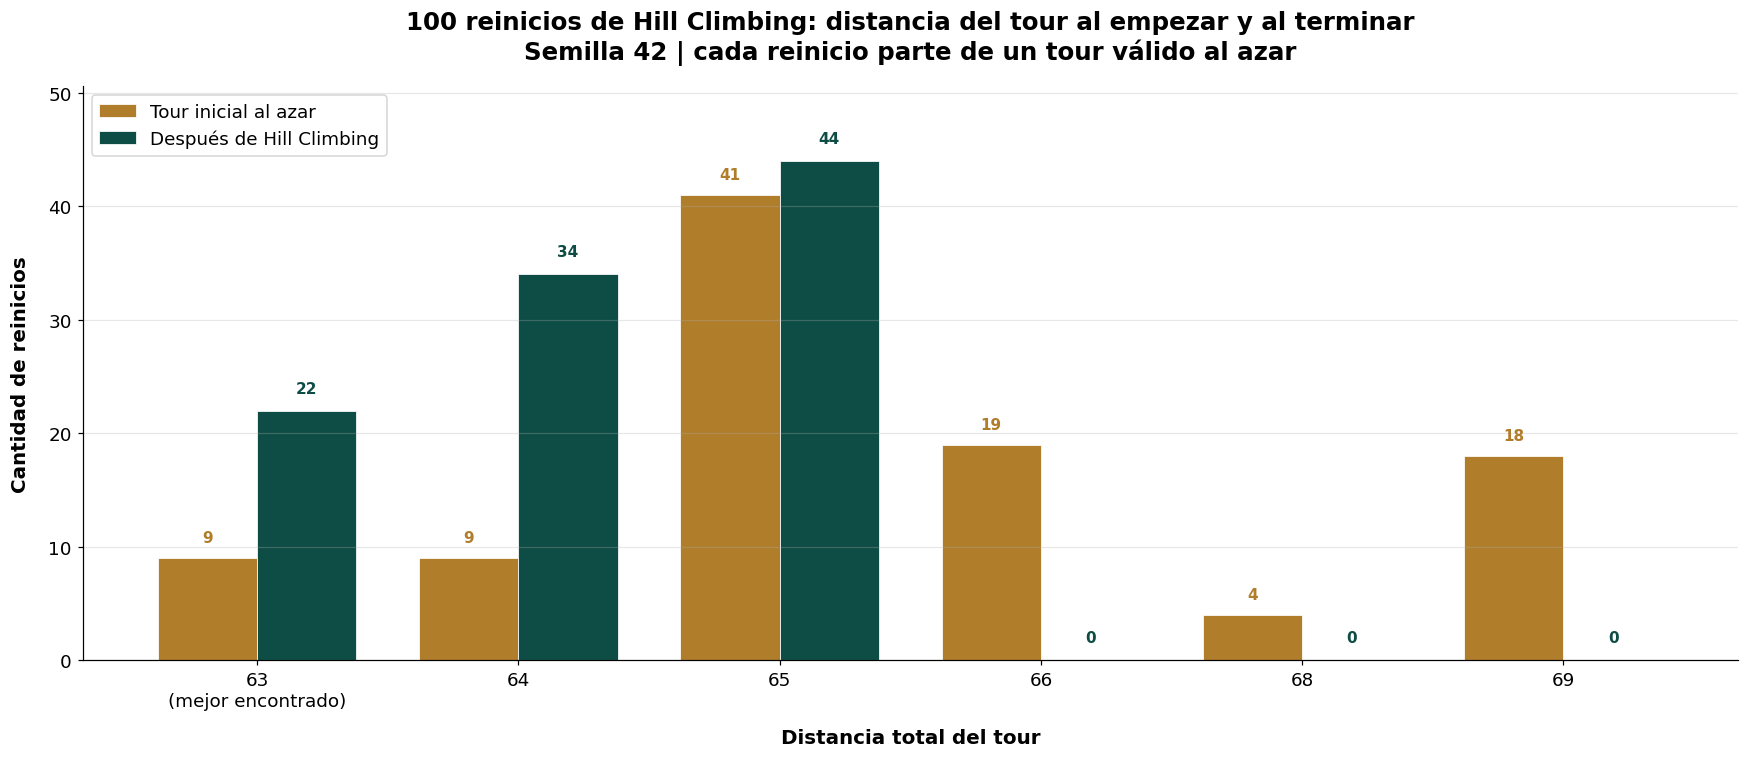

In [19]:
mejor_tour, mejor_dist, reinicios = hill_climbing_reinicios(distancias, 100, SEED)
print("Primeros 10 de los 100 reinicios:")
imprimir_tabla(reinicios[:10], ["reinicio", "intentos", "tour_inicial", "dist_inicial", "tour_final",
                                "dist_final", "movimientos"])

llegan = [r["reinicio"] for r in reinicios if r["dist_final"] == mejor_dist]
print(f"\nMejor tour con 100 reinicios: {formato(mejor_tour)} | distancia {mejor_dist}")
print(f"Reinicios que terminan en {mejor_dist}: {len(llegan)} de {len(reinicios)} (el primero es el {llegan[0]})")
print("Distancia inicial -> cantidad:", dict(sorted(Counter(r["dist_inicial"] for r in reinicios).items())))
print("Distancia final   -> cantidad:", dict(sorted(Counter(r["dist_final"] for r in reinicios).items())))
print(f"Barajadas promedio para obtener un tour válido: "
      f"{sum(r['intentos'] for r in reinicios) / len(reinicios):.1f}")
fig, ax = plot_reinicios(reinicios, mejor_dist, "01_hc_reinicios.png", etiqueta="mejor encontrado",
                         subtitulo=f"Semilla {SEED} | cada reinicio parte de un tour válido al azar")
plt.show()

Con 100 reinicios (semilla 42), el mejor tour es **1-3-5-7-6-4-2-1 con distancia 63**, 1 menos que Hill Climbing desde el tour inicial. Lo encuentra desde el primer reinicio. De los 100 reinicios, 22 terminan en 63, 34 en 64 y 44 en 65.

La gráfica muestra el efecto de cada escalada:

- **Antes** de Hill Climbing, los tours al azar van de 63 a 69.
- **Después**, ninguno queda arriba de 65. Hill Climbing siempre mejora lo que puede, pero 63, 64 y 65 son tres puntos donde se detiene.

Para conseguir un tour válido hicieron falta 34.2 barajadas en promedio. Cuadra con lo esperado: 720 órdenes / 20 válidos = 36.

### 7.5 Parte 1 | Extra: fuerza bruta de los tours válidos

In [20]:
validos = fuerza_bruta_tours(distancias)
optimo = validos[0][0]
print(f"Órdenes posibles de las ciudades 2 a 7: {math.factorial(len(distancias) - 1)} | "
      f"tours válidos: {len(validos)}\n")

# Run Hill Climbing from every valid tour to see where each one gets stuck.
filas = []
for d, t in validos:
    final, d_final, _ = hill_climbing(t, distancias)
    filas.append({"tour": t, "distancia": d, "hc_termina_en": d_final, "llega_al_optimo": d_final == optimo})
imprimir_tabla(filas, ["tour", "distancia", "hc_termina_en", "llega_al_optimo"])

exito = sum(f["llega_al_optimo"] for f in filas)
p = exito / len(filas)
print(f"\nÓptimo global: {optimo} ({sum(d == optimo for d, _ in validos)} tours: el mismo ciclo en los dos sentidos)")
print(f"Hill Climbing desde el tour inicial: {dist_hc} | mejor de 100 reinicios: {mejor_dist}")
print(f"Arranques válidos desde los que Hill Climbing llega al óptimo: {exito} de {len(filas)} ({p:.0%})")
print("Probabilidad de llegar al óptimo con k reinicios, 1 - (1 - p)^k:",
      {k: f"{1 - (1 - p) ** k:.1%}" for k in (1, 3, 5, 10, 100)})

Órdenes posibles de las ciudades 2 a 7: 720 | tours válidos: 20

tour            | distancia | hc_termina_en | llega_al_optimo
----------------+-----------+---------------+----------------
1-2-4-6-7-5-3-1 | 63        | 63            | sí             
1-3-5-7-6-4-2-1 | 63        | 63            | sí             
1-2-4-6-5-3-7-1 | 64        | 64            | no             
1-7-3-5-6-4-2-1 | 64        | 64            | no             
1-2-3-5-4-6-7-1 | 65        | 65            | no             
1-2-4-3-5-6-7-1 | 65        | 64            | no             
1-3-2-4-6-5-7-1 | 65        | 65            | no             
1-7-5-6-4-2-3-1 | 65        | 65            | no             
1-7-6-4-5-3-2-1 | 65        | 65            | no             
1-7-6-5-3-4-2-1 | 65        | 64            | no             
1-2-3-4-6-5-7-1 | 66        | 65            | no             
1-2-4-6-5-7-3-1 | 66        | 63            | sí             
1-3-7-5-6-4-2-1 | 66        | 63            | sí             
1-7-5

La fuerza bruta revisa los 720 órdenes y solo **20 son tours válidos**. El óptimo global es **63** y aparece dos veces: 1-2-4-6-7-5-3-1 y 1-3-5-7-6-4-2-1, que son el mismo ciclo en los dos sentidos. Con esto se confirma que:

- Hill Climbing desde el tour inicial (64) se quedó en un **óptimo local**.
- Los reinicios sí encontraron el **óptimo global**.

La columna `hc_termina_en` muestra a dónde lleva Hill Climbing desde cada arranque. Hay 8 tours donde se detiene sin moverse (los que terminan en su misma distancia): 2 de 63, 2 de 64 y 4 de 65. Solo **6 de los 20 arranques (30%)** llevan al óptimo. Como el tour al azar sale con la misma probabilidad entre los 20 válidos, cada reinicio tiene 30% de llegar a 63:

- Con 5 reinicios, la probabilidad de encontrarlo al menos una vez es 83.2%.
- Con 10 reinicios, 97.2%.
- Con 100, prácticamente 100%.

En la corrida de 7.4 llegaron 22 de 100, menos que los 30 esperados. Con 30% por reinicio, 22 o menos solo pasa en cerca del 5% de las corridas de 100: es una semilla algo desfavorable. Aun así no cambia la conclusión, porque el óptimo apareció desde el primer reinicio.

### 7.6 Parte 1 | Act. 6: gráfica del mejor recorrido

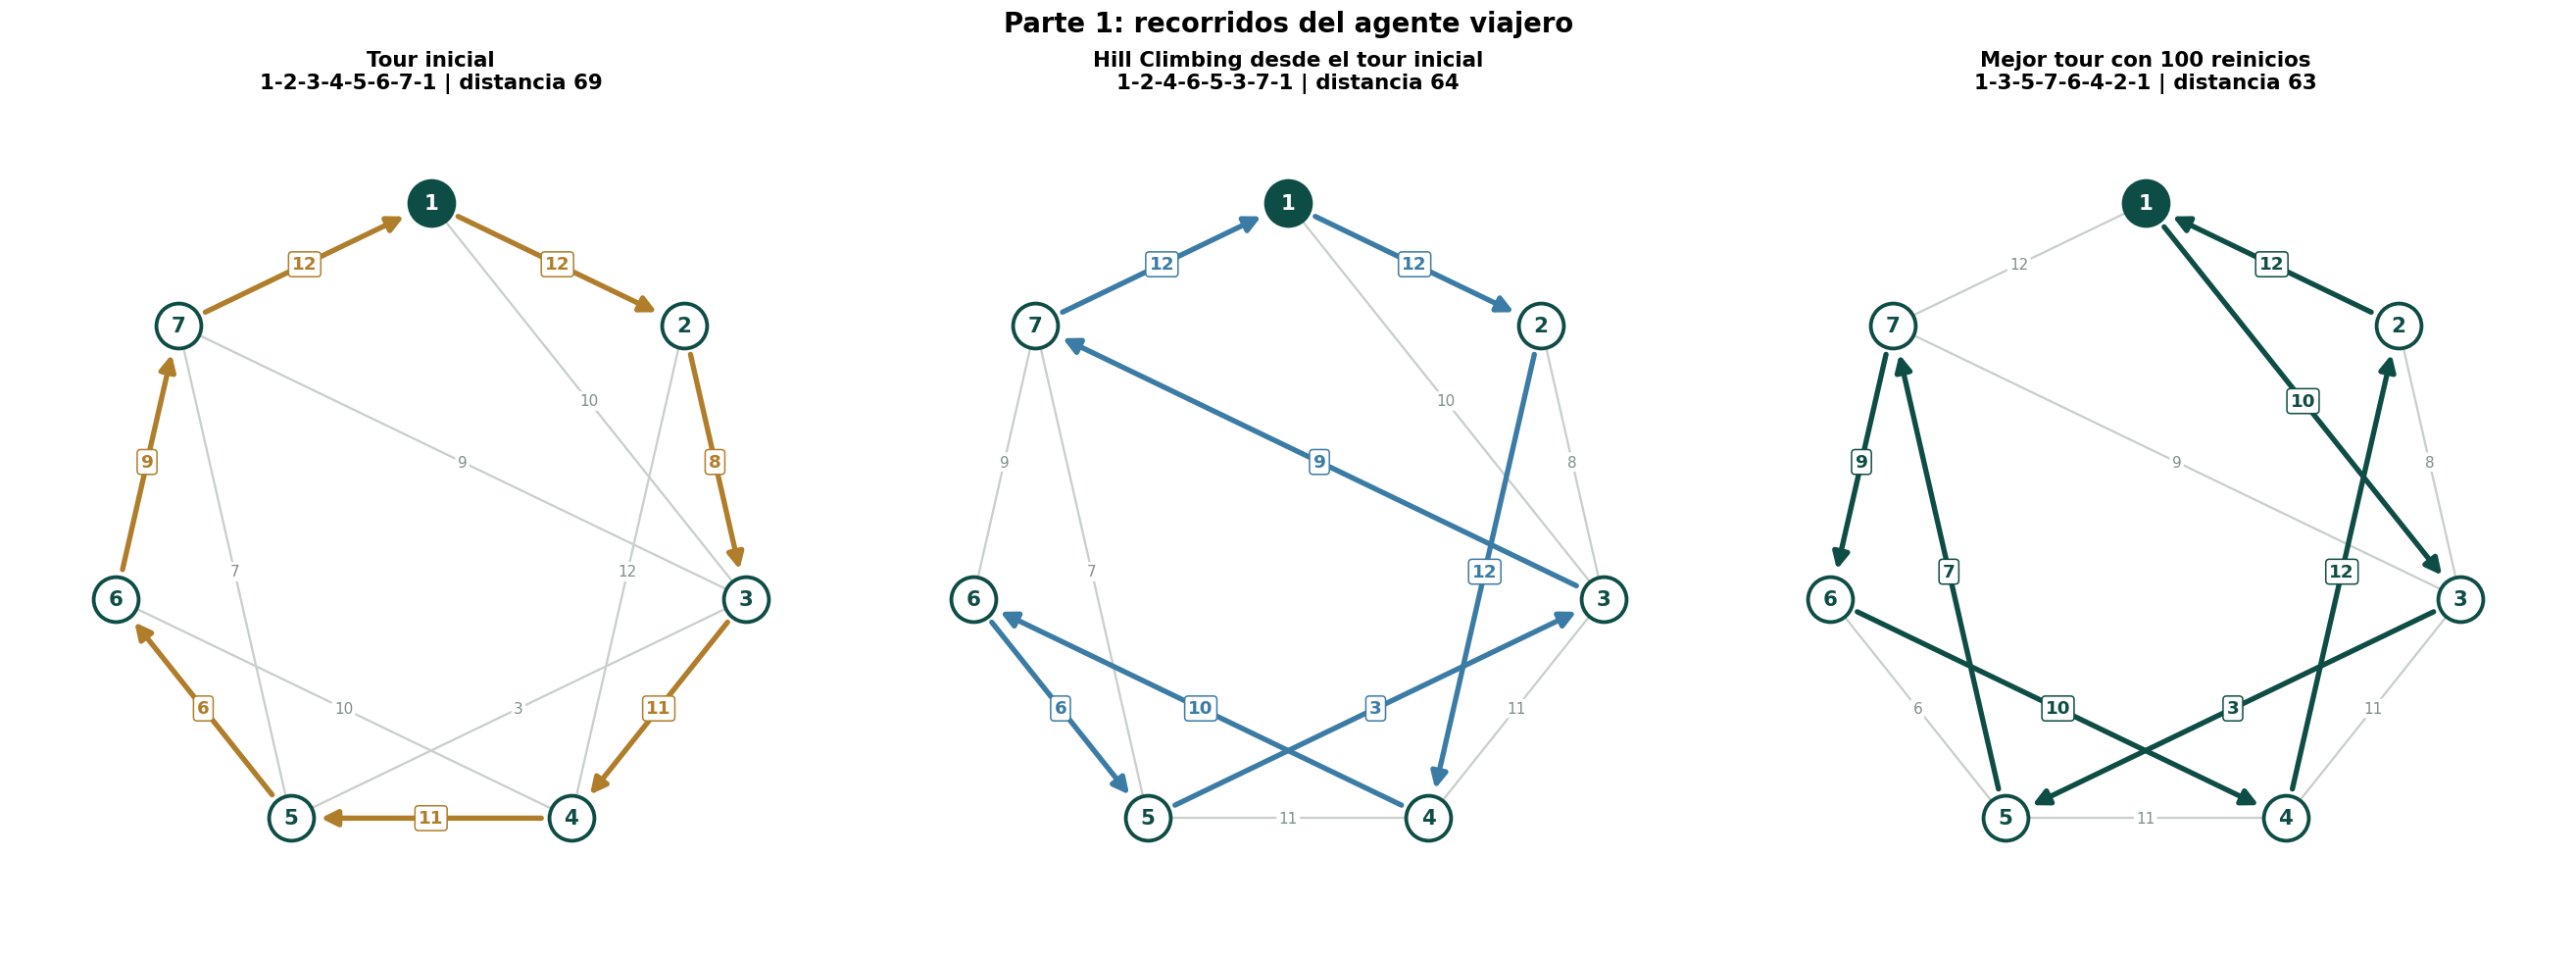

In [21]:
fig, axes = plot_tours([("Tour inicial", tour_inicial, ROLE["compare"]),
                        ("Hill Climbing desde el tour inicial", tour_hc, ROLE["model"]),
                        ("Mejor tour con 100 reinicios", mejor_tour, ROLE["actual"])],
                       distancias, "02_hc_mejor_recorrido.png", "Parte 1: recorridos del agente viajero")
plt.show()

Las posiciones de las ciudades son solo para dibujar. En gris están las carreteras que el tour no usa, y las flechas marcan el sentido del recorrido.

El panel del centro (64) y el de la derecha (63) explican por qué Hill Climbing se atasca. Leído en el mismo sentido, el óptimo es 1-2-4-6-7-5-3-1, así que los dos tours empiezan igual (1-2-4-6) y solo cambian en el final:

| Tour | Final del recorrido | Suma de esos tramos |
|---|---|---|
| Hill Climbing (64) | 6-5-3-7-1 | 6 + 3 + 9 + 12 = 30 |
| Óptimo (63) | 6-7-5-3-1 | 9 + 7 + 3 + 10 = 29 |

Pasar de 5-3-7 a 7-5-3 no es una inversión: hacen falta dos. La primera inversión (5-3-7 a 7-3-5) da 1-2-4-6-7-3-5-1, que no es válido porque no hay carretera de 5 a 1. El tour mejor está a dos pasos y el paso intermedio está prohibido, así que Hill Climbing, que solo mira un paso adelante, no lo puede ver.

#### Preguntas de análisis | Parte 1

**¿Qué representa una solución, un vecino y la función objetivo en este problema?**

- Una **solución** es un tour completo: sale de la ciudad 1, pasa exactamente una vez por las ciudades 2 a 7 y vuelve a la 1, usando solo carreteras que existen. Por ejemplo, 1-2-3-4-5-6-7-1.
- Un **vecino** es otro tour que se obtiene con un cambio pequeño: tomar un pedazo del recorrido y darle vuelta. Si en 1-2-3-4-5-6-7-1 se invierte el pedazo 3-4, queda 1-2-4-3-5-6-7-1. La ciudad 1 no se mueve. Con 7 ciudades hay 15 vecinos posibles, y aquí solo 5 de ellos son válidos.
- La **función objetivo** es la distancia total del tour, la suma de sus 7 tramos. Es el número que se quiere hacer lo más pequeño posible.

**¿Por qué Hill Climbing puede detenerse aunque exista un recorrido mejor?**

Porque solo compara el tour actual con sus vecinos inmediatos y solo acepta un cambio si mejora. Es como bajar una montaña con niebla, viendo solo un paso alrededor: si todos los pasos posibles suben o quedan igual, uno se detiene, aunque más allá haya un valle más profundo.

En este problema, desde el tour inicial llegó a 1-2-4-6-5-3-7-1 con 64. Ninguno de sus vecinos válidos mide menos de 64. El óptimo de 63 existe, pero para llegar a él hay que hacer dos inversiones, y la primera produce un tour que usa la carretera inexistente 5-1. Además, el algoritmo no acepta empates ni pasos peores, así que no tiene forma de cruzar ese punto intermedio.

**¿Qué efecto tuvieron los reinicios aleatorios?**

Convirtieron un método que dependía de la suerte del punto de partida en uno que encontró el óptimo:

- Una sola escalada desde el tour inicial termina en 64.
- Con 100 reinicios, el mejor resultado fue **63**, el óptimo global según la fuerza bruta. Lo alcanzaron 22 de los 100 reinicios, empezando por el primero.

Funciona porque cada reinicio empieza en otro lugar y cae en otra "zona" de atracción. El 30% de los arranques válidos lleva al óptimo, así que con 10 reinicios ya hay 97% de probabilidad de encontrarlo. El costo es correr Hill Climbing muchas veces, que aquí es barato porque cada escalada hace 2 movimientos o menos.

### 7.7 Parte 2 | Act. 7: heurística euclidiana

In [22]:
caminos = get_caminos()
grafo = construir_distancias(caminos)
coordenadas = get_coordenadas()
meta = "T"
h_real = costos_reales(grafo, coordenadas, meta)

print("h(n) euclidiana contra el costo real que falta, h*(n):")
filas_h = []
for n, (x, y) in coordenadas.items():
    hn = heuristica(n, meta, coordenadas)
    filas_h.append({"estacion": n, "x": x, "y": y, "h": hn, "h_real": h_real[n],
                    "h/h_real": hn / h_real[n] if h_real[n] else None, "admisible": hn <= h_real[n]})
imprimir_tabla(filas_h, ["estacion", "x", "y", "h", "h_real", "h/h_real", "admisible"])

revision = revisar_heuristica(caminos, coordenadas, meta)
print("\nConsistencia por camino, |h(u) - h(v)| <= distancia:")
imprimir_tabla(revision, ["camino", "distancia", "h_u", "h_v", "dif_h", "consistente"])
holgura = min(r["distancia"] - r["dif_h"] for r in revision)
print(f"\nCaminos consistentes: {sum(r['consistente'] for r in revision)} de {len(revision)} | "
      f"holgura mínima (distancia - dif_h): {holgura:.2f}")

h(n) euclidiana contra el costo real que falta, h*(n):
estacion | x    | y     | h    | h_real | h/h_real | admisible
---------+------+-------+------+--------+----------+----------
O        | 0.00 | 0.00  | 9.01 | 13     | 0.69     | sí       
A        | 1.50 | 1.20  | 7.53 | 11     | 0.68     | sí       
B        | 2.50 | 0.00  | 6.52 | 9      | 0.72     | sí       
C        | 2.80 | -0.80 | 6.33 | 10     | 0.63     | sí       
D        | 5.50 | 1.00  | 3.54 | 5      | 0.71     | sí       
E        | 5.20 | 0.20  | 3.81 | 6      | 0.64     | sí       
T        | 9.00 | 0.50  | 0.00 | 0      | -        | sí       

Consistencia por camino, |h(u) - h(v)| <= distancia:
camino | distancia | h_u  | h_v  | dif_h | consistente
-------+-----------+------+------+-------+------------
O-A    | 2         | 9.01 | 7.53 | 1.48  | sí         
O-B    | 5         | 9.01 | 6.52 | 2.49  | sí         
O-C    | 4         | 9.01 | 6.33 | 2.68  | sí         
A-B    | 2         | 7.53 | 6.52 | 1.01  | sí    

La heurística euclidiana es **admisible** en las 7 estaciones: nunca pasa del costo real que falta. Es bastante conservadora: vale entre 63% y 72% del costo real. Por ejemplo, desde O la línea recta a T mide 9.01 y el mejor camino cuesta 13. Pasa porque los caminos del parque son entre 1.4 y 1.6 veces más largos que la línea recta.

También es **consistente** en los 12 caminos: en ninguno h baja más de lo que mide el camino. El caso más justo es B-E: el camino mide 3 y h baja 2.71, con 0.29 de holgura. Por ser consistente, A\* puede cerrar cada nodo la primera vez que lo expande sin perder la ruta óptima.

### 7.8 Parte 2 | Act. 8 a 10: A\* paso a paso

In [23]:
ruta_a, costo_a, registro_a = a_estrella(grafo, coordenadas, "O", meta)
imprimir_tabla(registro_a, ["paso", "expandido", "g", "h", "f", "lista_abierta"])
print(f"\nRuta encontrada: {formato(ruta_a)}")
print(f"Costo total: {' + '.join(str(grafo[a][b]) for a, b in zip(ruta_a, ruta_a[1:]))} = {costo_a}")
print(f"Nodos expandidos: {len(registro_a)} de {len(grafo)}")

paso | expandido | g  | h    | f     | lista_abierta               
-----+-----------+----+------+-------+-----------------------------
1    | O         | 0  | 9.01 | 9.01  | A(9.53), C(10.33), B(11.52) 
2    | A         | 2  | 7.53 | 9.53  | C(10.33), B(10.52), D(12.54)
3    | C         | 4  | 6.33 | 10.33 | B(10.52), E(11.81), D(12.54)
4    | B         | 4  | 6.52 | 10.52 | E(10.81), D(11.54)          
5    | E         | 7  | 3.81 | 10.81 | D(11.54), T(14.00)          
6    | D         | 8  | 3.54 | 11.54 | T(13.00)                    
7    | T         | 13 | 0.00 | 13.00 | vacía                       

Ruta encontrada: O-A-B-D-T
Costo total: 2 + 2 + 4 + 5 = 13
Nodos expandidos: 7 de 7


A\* encuentra la ruta **O-A-B-D-T con costo 2 + 2 + 4 + 5 = 13**. Los momentos que muestran cómo funciona:

- **Paso 1.** Al expandir O, B entra a la lista abierta con g = 5 por el camino directo O-B.
- **Paso 2.** Al expandir A, aparece un camino más barato a B (O-A-B, g = 4), así que su f baja de 11.52 a 10.52.
- **Paso 3.** C (f = 10.33) sale antes que B (10.52), porque en línea recta C está un poco más cerca de T (h = 6.33 contra 6.52).
- **Paso 4.** Al expandir B, D mejora de 12.54 (por A-D) a 11.54 (por B-D).
- **Paso 5.** Al expandir E, T aparece por primera vez con f = 14 (O-A-B-E-T), pero A\* **no se detiene**. Todavía hay nodos con f menor que podrían llevar a algo más barato.
- **Paso 6.** Expandir D encuentra T con g = 13.
- **Paso 7.** T sale de la lista abierta y la búsqueda termina.

Se expandieron los 7 nodos de la red. El f de cada nodo expandido nunca baja (9.01, 9.53, 10.33, ..., 13.00), que es lo que garantiza una heurística consistente.

### 7.9 Parte 2 | Act. 11: A\* con h(n) = 0

In [24]:
ruta_0, costo_0, registro_0 = a_estrella(grafo, coordenadas, "O", meta, h=heuristica_cero)
print("A* con h(n) = 0:")
imprimir_tabla(registro_0, ["paso", "expandido", "g", "h", "f", "lista_abierta"])

ruta_p, costo_p, registro_p = a_estrella(grafo, coordenadas, "O", meta, h=heuristica_desde_tabla(h_real))
print("\nComparación de tres heurísticas:")
imprimir_tabla([{"heuristica": nombre, "ruta": r, "costo": c, "expandidos": len(reg),
                 "orden_de_expansion": [x["expandido"] for x in reg]}
                for nombre, r, c, reg in [("h = 0 (Dijkstra)", ruta_0, costo_0, registro_0),
                                          ("euclidiana", ruta_a, costo_a, registro_a),
                                          ("perfecta h*", ruta_p, costo_p, registro_p)]],
               ["heuristica", "ruta", "costo", "expandidos", "orden_de_expansion"])

# Why the Euclidean heuristic saves nothing here: A* must expand every node with g*(n) + h(n) < optimal cost.
g_real = costos_reales(grafo, coordenadas, "O")
print(f"\nNodos con g*(n) + h(n) menor que el costo óptimo {costo_a} (A* tiene que expandirlos):")
imprimir_tabla([{"estacion": n, "g_real": g_real[n], "h": heuristica(n, meta, coordenadas),
                 "g_real+h": g_real[n] + heuristica(n, meta, coordenadas),
                 "menor_que_optimo": g_real[n] + heuristica(n, meta, coordenadas) < costo_a}
                for n in sorted(grafo, key=lambda n: g_real[n] + heuristica(n, meta, coordenadas))],
               ["estacion", "g_real", "h", "g_real+h", "menor_que_optimo"])

rutas = rutas_simples(grafo, "O", meta)
print(f"\nReferencia por fuerza bruta: {len(rutas)} rutas simples de O a T. Las 5 más baratas:")
imprimir_tabla([{"ruta": r, "costo": c} for c, r in rutas[:5]], ["ruta", "costo"])

A* con h(n) = 0:
paso | expandido | g  | h    | f     | lista_abierta            
-----+-----------+----+------+-------+--------------------------
1    | O         | 0  | 0.00 | 0.00  | A(2.00), C(4.00), B(5.00)
2    | A         | 2  | 0.00 | 2.00  | B(4.00), C(4.00), D(9.00)
3    | B         | 4  | 0.00 | 4.00  | C(4.00), E(7.00), D(8.00)
4    | C         | 4  | 0.00 | 4.00  | E(7.00), D(8.00)         
5    | E         | 7  | 0.00 | 7.00  | D(8.00), T(14.00)        
6    | D         | 8  | 0.00 | 8.00  | T(13.00)                 
7    | T         | 13 | 0.00 | 13.00 | vacía                    

Comparación de tres heurísticas:
heuristica       | ruta      | costo | expandidos | orden_de_expansion
-----------------+-----------+-------+------------+-------------------
h = 0 (Dijkstra) | O-A-B-D-T | 13    | 7          | O-A-B-C-E-D-T     
euclidiana       | O-A-B-D-T | 13    | 7          | O-A-C-B-E-D-T     
perfecta h*      | O-A-B-D-T | 13    | 5          | O-A-B-D-T         

Nodos co

Con h(n) = 0 la ruta y el costo son los mismos: **O-A-B-D-T, 13**. Como h vale 0, f = g y la lista abierta se ordena solo por la distancia ya recorrida desde O. Eso es exactamente **Dijkstra**: expande primero lo más cercano al origen, en cualquier dirección (O a 0, A a 2, B y C a 4, E a 7, D a 8, T a 13).

En esta red la heurística euclidiana **no ahorra expansiones**: las dos versiones expanden los 7 nodos. Solo cambia el orden (C antes que B). La tabla de g\*(n) + h(n) explica por qué. A\* tiene que expandir todo nodo con g\*(n) + h(n) menor que el costo óptimo, porque no puede descartarlo. Aquí los 6 nodos distintos de T quedan entre 9.01 y 11.54, todos por debajo de 13. La línea recta subestima demasiado (63% a 72% del costo real) para descartar alguno.

La heurística perfecta h\*(n) muestra lo que sí puede lograr una heurística informada: expande **5 nodos**, justo los de la ruta, y nunca toca C ni E.

La fuerza bruta encuentra 28 rutas simples de O a T y confirma el óptimo de 13. Hay **dos rutas empatadas**: O-A-B-D-T y O-A-B-E-D-T. A\* devuelve la primera porque D recibió g = 8 por B en el paso 4. En el paso 5, llegar a D por E también da 8, y como no es estrictamente menor, el padre de D se queda en B.

### 7.10 Parte 2 | Act. 12: gráfica de la red

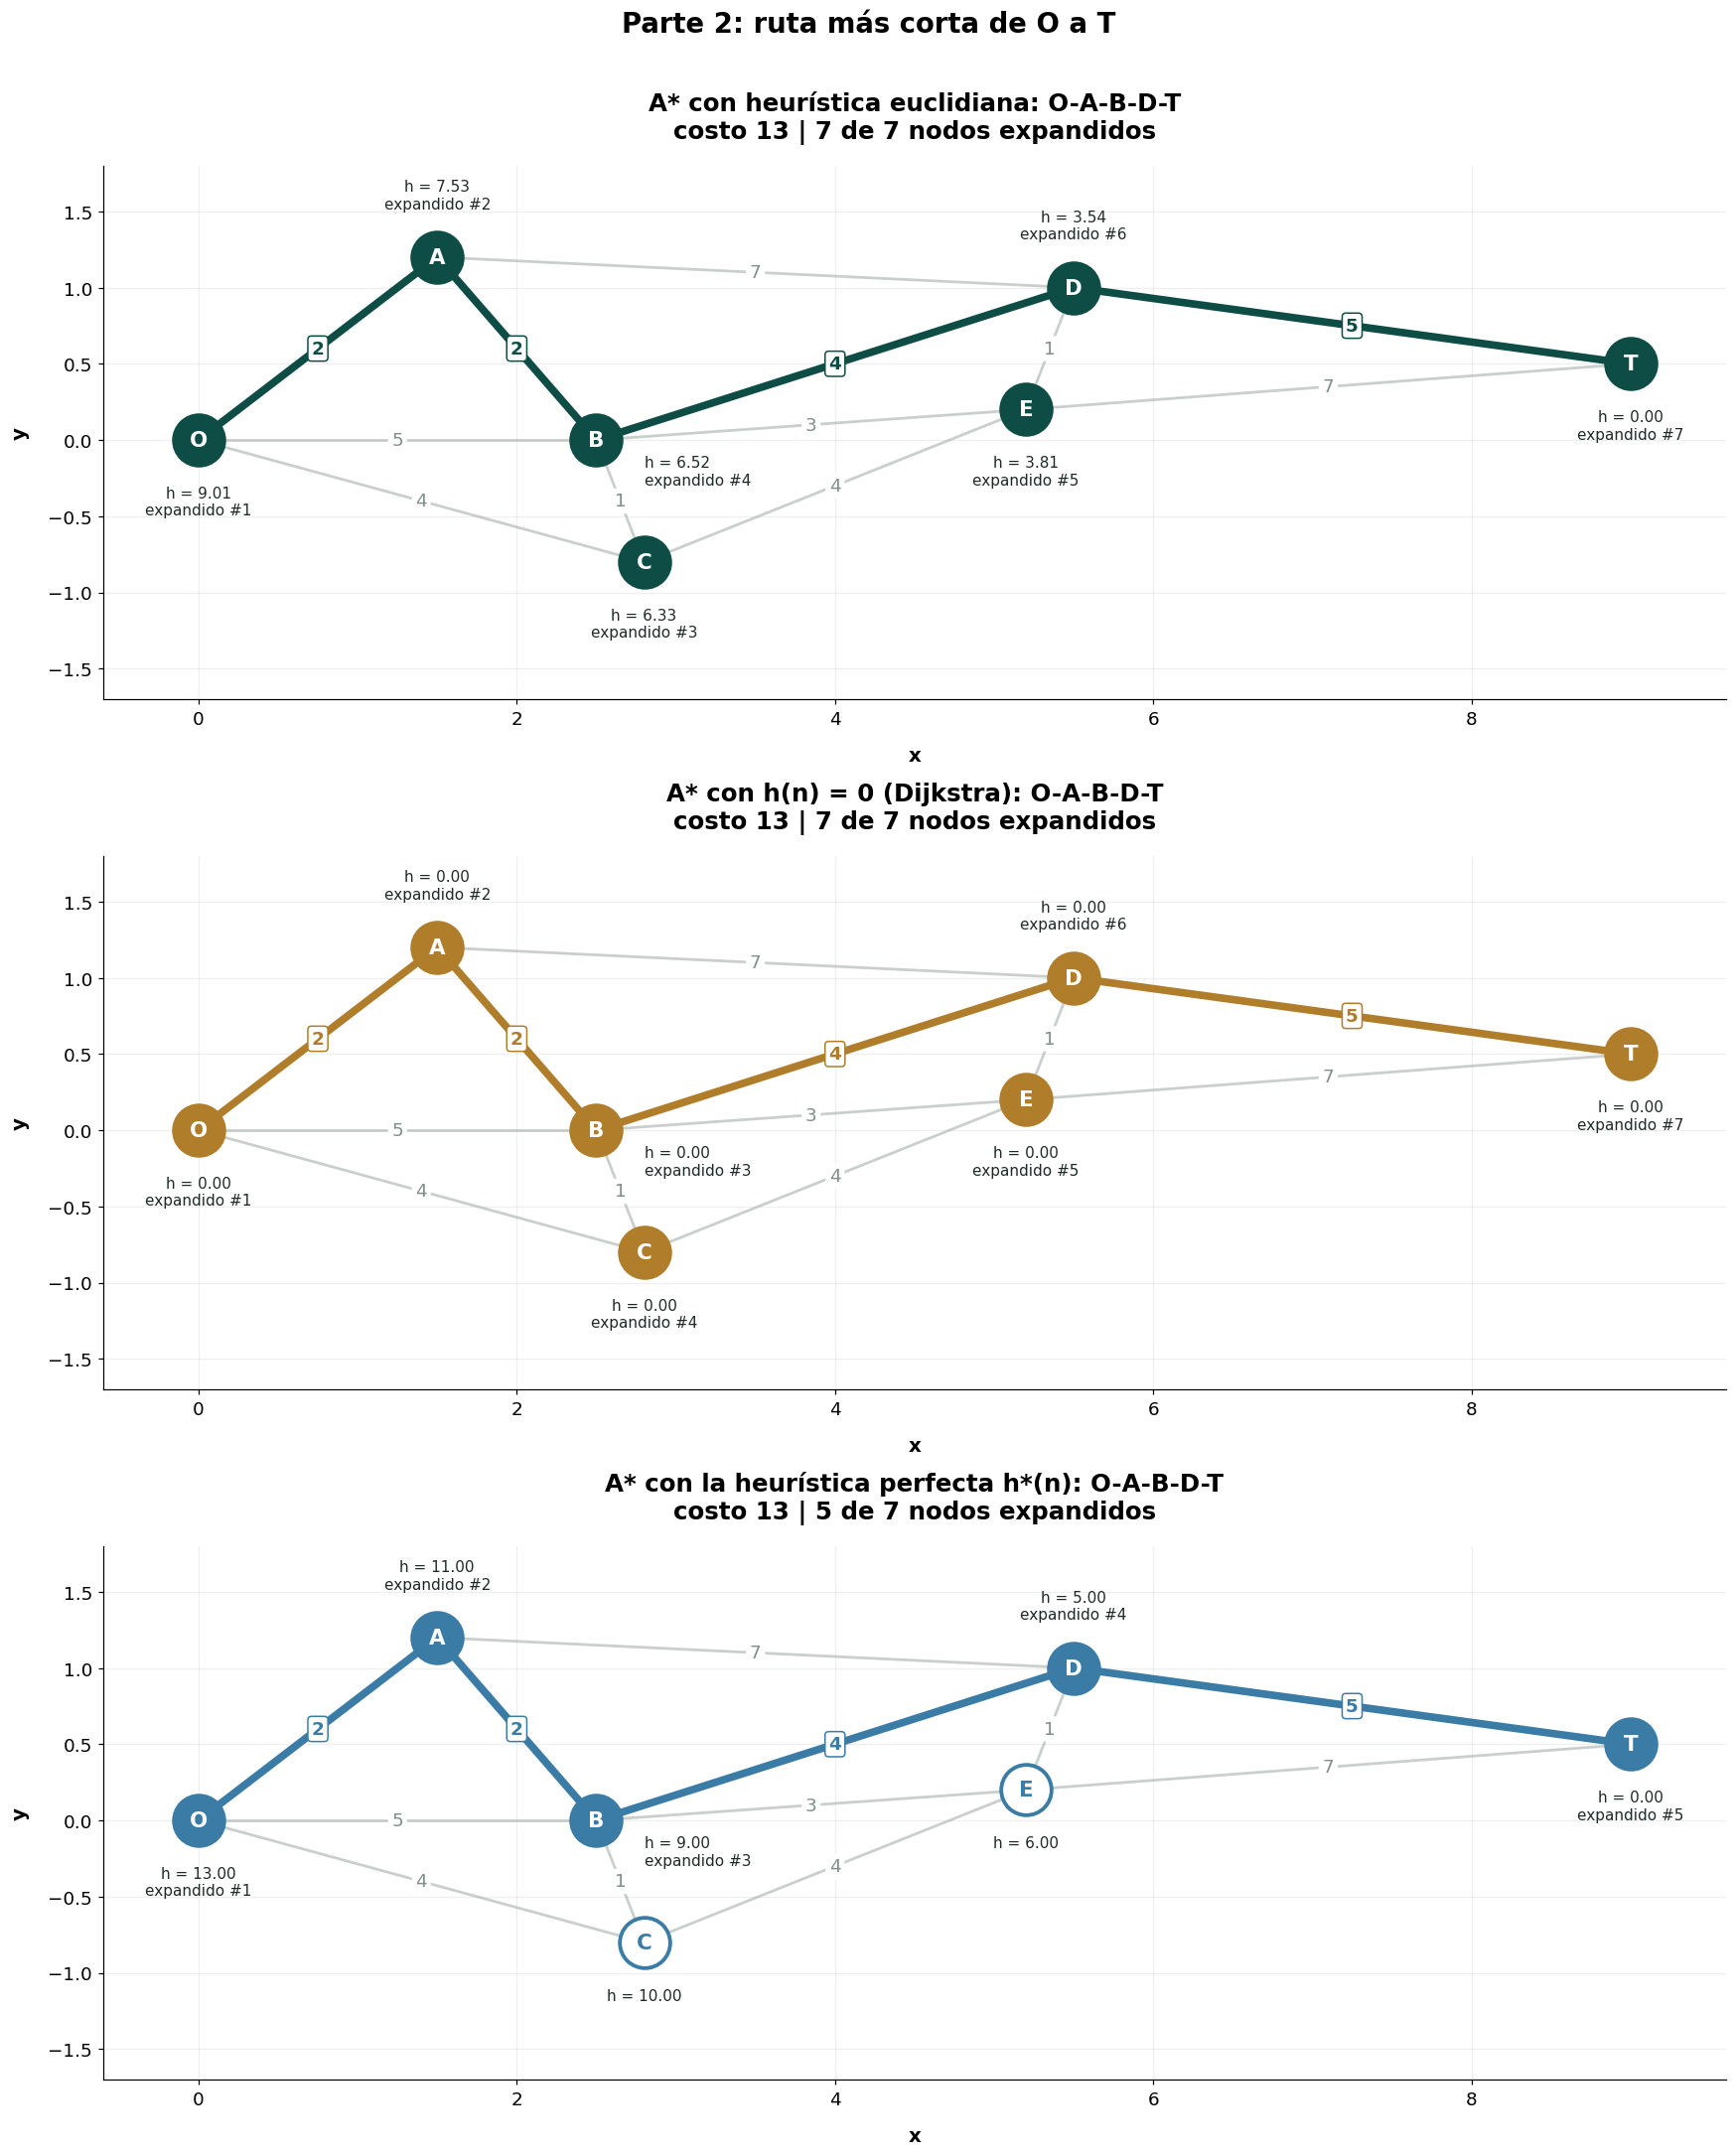

In [25]:
fig, axes = plot_red(grafo, coordenadas,
                     [("A* con heurística euclidiana", ruta_a, [r["expandido"] for r in registro_a],
                       ROLE["actual"], heuristica),
                      ("A* con h(n) = 0 (Dijkstra)", ruta_0, [r["expandido"] for r in registro_0],
                       ROLE["compare"], heuristica_cero),
                      ("A* con la heurística perfecta h*(n)", ruta_p, [r["expandido"] for r in registro_p],
                       ROLE["model"], heuristica_desde_tabla(h_real))],
                     "03_astar_red.png", "Parte 2: ruta más corta de O a T",
                     lado_nota={"A": "arriba", "D": "arriba", "B": "derecha"})
plt.show()

La red está dibujada en sus coordenadas reales; el número en cada camino es su distancia y la ruta va en grueso. Los nodos rellenos son los que cada versión expandió, con su orden. Las tres búsquedas llegan a la misma ruta de costo 13:

- **Euclidiana:** expande los 7 nodos.
- **h = 0 (Dijkstra):** también 7, en distinto orden (B antes que C).
- **Perfecta h\*:** solo 5. C y E quedan vacíos porque nunca se expandieron.

La gráfica deja ver por qué la euclidiana no descarta nada: T está a la derecha de todo, así que ninguna estación queda "detrás" del origen o lejos de la dirección de la meta. Todas parecen prometedoras en línea recta.

#### Preguntas de análisis | Parte 2

**¿Qué información aporta g(n)? ¿Qué información aporta h(n)?**

- **g(n)** es lo que ya se sabe con certeza: cuánto costó llegar desde O hasta n por el mejor camino encontrado hasta ahora. Cuando A\* expandió B, g(B) = 4 porque el camino O-A-B mide 2 + 2.
- **h(n)** es una estimación de lo que falta para llegar a T. Aquí es la distancia en línea recta, calculada con las coordenadas sin recorrer ningún camino. Para B, h = 6.52, cuando lo que realmente falta es 9.

Al sumarlas, f(n) = g(n) + h(n) estima el costo total de una ruta que pase por n. A\* siempre continúa por el nodo con menor f, es decir, por la ruta que parece más barata completa y no solo por lo recorrido.

**¿Por qué una heurística útil puede reducir la cantidad de nodos explorados?**

A\* nunca expande un nodo cuyo f sea mayor que el costo de la ruta óptima, porque antes saca a la meta de la lista abierta. Una buena heurística sube el f de los nodos que van en mala dirección o que están lejos de la meta. Esos nodos se quedan esperando en la lista abierta y nunca se expanden. Entre más se acerque h al costo real (sin pasarse), más nodos quedan fuera.

Los números de 7.9 muestran los dos extremos:

- Con la heurística perfecta, h\*(n), A\* expande solo los 5 nodos de la ruta.
- Con la euclidiana expande los 7, igual que Dijkstra. En esta red pequeña todas las estaciones quedan en dirección a T y los caminos son mucho más largos que la línea recta, así que ningún nodo llega a f mayor que 13.

En una red grande, como un mapa de una ciudad, la línea recta sí descarta la mayoría de las calles que se alejan de la meta. Ahí está el ahorro.

**¿Qué ocurre conceptualmente cuando h(n) = 0?**

A\* deja de tener sentido de dirección: f = g, así que expande los nodos en orden de distancia desde el origen, como una mancha que crece igual hacia todos lados. Eso es el algoritmo de **Dijkstra**. Sigue siendo óptimo, porque h = 0 nunca sobreestima, y aquí encontró la misma ruta de costo 13. Pero en general explora más, porque no distingue entre un nodo que se acerca a la meta y uno que se aleja. Dijkstra es el caso de A\* sin información sobre la meta.

### 7.11 Parte 3A | Act. 13: red residual

In [26]:
tramos = get_tramos()
capacidades, costos = construir_capacidades_costos(tramos)
residual_inicial = construir_residual(capacidades)

filas_res = [{"desde": u, "hacia": v, "capacidad_residual": c, "tipo": "original" if v in capacidades[u] else "regreso"}
             for u in residual_inicial for v, c in residual_inicial[u].items()]
imprimir_tabla(filas_res, ["desde", "hacia", "capacidad_residual", "tipo"])
n_regreso = sum(f["tipo"] == "regreso" for f in filas_res)
print(f"\nAristas originales: {len(filas_res) - n_regreso} | de regreso: {n_regreso} | total en la red residual: {len(filas_res)}")
print(f"Capacidad que sale de S: {sum(capacidades['S'].values())} | "
      f"capacidad que entra a T: {sum(capacidades[u].get('T', 0) for u in capacidades)}")

desde | hacia | capacidad_residual | tipo    
------+-------+--------------------+---------
S     | A     | 5                  | original
S     | B     | 7                  | original
S     | C     | 4                  | original
A     | S     | 0                  | regreso 
A     | B     | 1                  | original
A     | D     | 3                  | original
B     | S     | 0                  | regreso 
B     | A     | 0                  | regreso 
B     | C     | 2                  | original
B     | D     | 4                  | original
B     | E     | 5                  | original
C     | S     | 0                  | regreso 
C     | B     | 0                  | regreso 
C     | E     | 4                  | original
D     | A     | 0                  | regreso 
D     | B     | 0                  | regreso 
D     | T     | 9                  | original
D     | E     | 0                  | regreso 
E     | B     | 0                  | regreso 
E     | C     | 0                 

La red residual tiene **24 aristas**:

- Las 12 originales empiezan con toda su capacidad libre.
- Las 12 de regreso empiezan en 0, porque todavía no se ha mandado nada que se pueda devolver.

Antes de correr el algoritmo ya hay dos límites a la vista: de S salen como máximo 16 unidades y a T entran como máximo 15. Así que el flujo máximo no puede pasar de 15.

### 7.12 Parte 3A | Act. 14 a 16: Edmonds-Karp

In [27]:
flujo_max, flujos_ek, registro_ek, residual_ek = edmonds_karp(capacidades, "S", "T")
imprimir_tabla(registro_ek, ["iteracion", "camino", "cuello_de_botella", "tramo_limitante", "usa_regreso",
                             "flujo_enviado", "flujo_acumulado"])
print(f"\nFlujo máximo de S a T: {flujo_max}\n")

print("Flujo utilizado en cada tramo:")
imprimir_tabla([{"tramo": [u, v], "flujo": f, "capacidad": capacidades[u][v], "uso": f"{f / capacidades[u][v]:.0%}",
                 "saturado": f == capacidades[u][v]} for (u, v), f in flujos_ek.items()],
               ["tramo", "flujo", "capacidad", "uso", "saturado"])

iteracion | camino    | cuello_de_botella | tramo_limitante | usa_regreso | flujo_enviado | flujo_acumulado
----------+-----------+-------------------+-----------------+-------------+---------------+----------------
1         | S-A-D-T   | 3                 | A-D             | no          | 3             | 3              
2         | S-B-D-T   | 4                 | B-D             | no          | 4             | 7              
3         | S-B-E-T   | 3                 | S-B             | no          | 3             | 10             
4         | S-C-E-T   | 3                 | E-T             | no          | 3             | 13             
5         | S-C-E-D-T | 1                 | S-C, C-E, E-D   | no          | 1             | 14             

Flujo máximo de S a T: 14

Flujo utilizado en cada tramo:
tramo | flujo | capacidad | uso  | saturado
------+-------+-----------+------+---------
S-A   | 3     | 5         | 60%  | no      
S-B   | 7     | 7         | 100% | sí      
S-C   | 4

Edmonds-Karp necesita **5 caminos aumentantes** para llegar a un flujo máximo de **14**:

| Iteración | Camino | Envía | Por qué esa cantidad |
|---|---|---|---|
| 1 | S-A-D-T | 3 | Limita A-D, que tiene capacidad 3 |
| 2 | S-B-D-T | 4 | Limita B-D |
| 3 | S-B-E-T | 3 | A S-B solo le quedan 3 de 7 |
| 4 | S-C-E-T | 3 | A E-T solo le quedan 3 de 6 |
| 5 | S-C-E-D-T | 1 | S-C, C-E y E-D quedan con 1 libre a la vez |

Los cuatro primeros caminos tienen 3 tramos y el último 4. BFS siempre agota primero los caminos más cortos. Después de la iteración 5 ya no hay camino de S a T con capacidad libre. Ningún camino necesitó una arista de regreso.

En la tabla de tramos:

- 7 de los 12 tramos quedan **saturados** (al 100%).
- A-B y B-C no se usan.
- D-T queda en 8 de 9: le sobra capacidad, pero no le llega más flujo.

### 7.13 Parte 3A | Act. 17: verificación de capacidad y conservación

In [28]:
por_tramo, por_nodo = verificar_flujo(capacidades, flujos_ek, "S", "T")
print("Capacidad: 0 <= flujo <= capacidad en cada tramo")
imprimir_tabla(por_tramo, ["tramo", "flujo", "capacidad", "cumple"])
print("\nConservación: en cada nodo intermedio entra lo mismo que sale")
imprimir_tabla(por_nodo, ["nodo", "entra", "sale", "cumple"])

sale_s = sum(f for (u, _), f in flujos_ek.items() if u == "S")
entra_t = sum(f for (_, v), f in flujos_ek.items() if v == "T")
print(f"\nTramos que cumplen capacidad: {sum(r['cumple'] for r in por_tramo)} de {len(por_tramo)} | "
      f"nodos que conservan flujo: {sum(r['cumple'] for r in por_nodo)} de {len(por_nodo)}")
print(f"Sale de S: {sale_s} | entra a T: {entra_t} | flujo máximo: {flujo_max}")
assert all(r["cumple"] for r in por_tramo + por_nodo) and sale_s == entra_t == flujo_max

Capacidad: 0 <= flujo <= capacidad en cada tramo
tramo | flujo | capacidad | cumple
------+-------+-----------+-------
S-A   | 3     | 5         | sí    
S-B   | 7     | 7         | sí    
S-C   | 4     | 4         | sí    
A-B   | 0     | 1         | sí    
A-D   | 3     | 3         | sí    
B-C   | 0     | 2         | sí    
B-D   | 4     | 4         | sí    
B-E   | 3     | 5         | sí    
C-E   | 4     | 4         | sí    
D-T   | 8     | 9         | sí    
E-D   | 1     | 1         | sí    
E-T   | 6     | 6         | sí    

Conservación: en cada nodo intermedio entra lo mismo que sale
nodo | entra | sale | cumple
-----+-------+------+-------
A    | 3     | 3    | sí    
B    | 7     | 7    | sí    
C    | 4     | 4    | sí    
D    | 8     | 8    | sí    
E    | 7     | 7    | sí    

Tramos que cumplen capacidad: 12 de 12 | nodos que conservan flujo: 5 de 5
Sale de S: 14 | entra a T: 14 | flujo máximo: 14


La verificación pasa completa:

- Los 12 tramos respetan su capacidad.
- Los 5 nodos intermedios conservan el flujo: A recibe y entrega 3, B 7, C 4, D 8 y E 7.
- De S salen 14 y a T llegan 14, igual al flujo máximo.

El `assert` al final detiene el notebook si alguna de estas condiciones falla, así que la verificación no depende de leer la tabla.

### 7.14 Parte 3A | Extra: corte mínimo

Nodos que se alcanzan desde S en la red residual final: S, A, B, C, E
Tramos que cruzan el corte (de ese grupo hacia el resto):
tramo | capacidad | flujo
------+-----------+------
A-D   | 3         | 3    
B-D   | 4         | 4    
E-D   | 1         | 1    
E-T   | 6         | 6    

Capacidad del corte: 14 | flujo máximo: 14

Capacidad de algunos cortes S | T:
corte                          | lado_de_S        | capacidad
-------------------------------+------------------+----------
todo lo que sale de S          | S                | 16       
todo lo que entra a T          | S, A, B, C, D, E | 15       
tramos que llegan a D, más E-T | S, A, B, C, E    | 14       


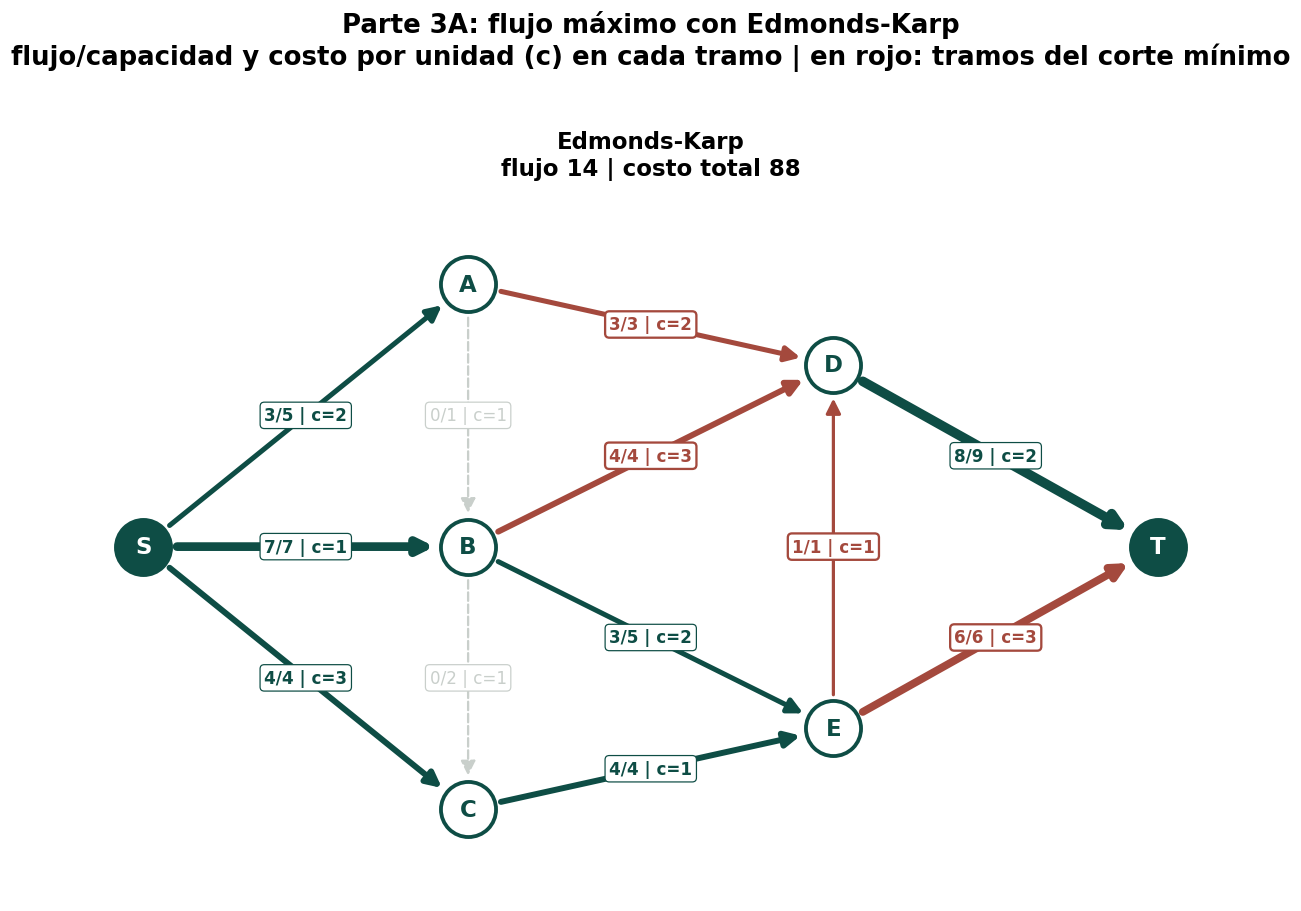

In [29]:
lado_s, corte = corte_minimo(residual_ek, capacidades, "S")
print(f"Nodos que se alcanzan desde S en la red residual final: {", ".join(lado_s)}")
print("Tramos que cruzan el corte (de ese grupo hacia el resto):")
imprimir_tabla([{"tramo": [u, v], "capacidad": capacidades[u][v], "flujo": flujos_ek[(u, v)]} for u, v in corte],
               ["tramo", "capacidad", "flujo"])
print(f"\nCapacidad del corte: {capacidad_corte(capacidades, lado_s)} | flujo máximo: {flujo_max}")

# Other natural cuts, to see which one is the real limit.
otros = [("todo lo que sale de S", ["S"]),
         ("todo lo que entra a T", [n for n in capacidades if n != "T"]),
         ("tramos que llegan a D, más E-T", lado_s)]
print("\nCapacidad de algunos cortes S | T:")
imprimir_tabla([{"corte": nombre, "lado_de_S": ", ".join(lado), "capacidad": capacidad_corte(capacidades, lado)}
                for nombre, lado in otros], ["corte", "lado_de_S", "capacidad"])

fig, axes = plot_flujos(capacidades, costos, [("Edmonds-Karp", flujos_ek, ROLE["actual"])],
                        "04_flujo_maximo.png", "Parte 3A: flujo máximo con Edmonds-Karp", corte=corte)
plt.show()

Al terminar, desde S todavía se alcanzan S, A, B, C y E en la red residual, pero no D ni T. Los tramos originales que salen de ese grupo son A-D (3), B-D (4), E-D (1) y E-T (6). Los 4 están llenos y su capacidad suma **14, exactamente el flujo máximo**.

Esa es la prueba de que 14 es lo máximo posible: toda unidad que va de S a T tiene que cruzar alguno de esos 4 tramos, y entre todos solo caben 14. Los cortes obvios no son el límite real:

- Todo lo que sale de S suma 16.
- Todo lo que entra a T suma 15.

La red se estrangula antes, en la llegada a D. D-T aguanta 9, pero a D solo pueden entrar 3 + 4 + 1 = 8. El tramo E-T (6) queda lleno por el otro lado.

En la gráfica, los tramos del corte están en rojo, el grosor de cada flecha crece con su flujo y los tramos sin flujo van punteados.

### 7.15 Parte 3B | Act. 18: estado inicial de cada arista

In [30]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.16 Parte 3B | Act. 19 a 23: costo mínimo paso a paso

In [31]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.17 Parte 3B | Act. 24: reporte final

In [32]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.18 Parte 3B | Extra: costo de la distribución de Edmonds-Karp

In [33]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

## 8. Conclusiones

TODO: respuesta a la pregunta con números, limitaciones y siguientes pasos.